# GVH Dynamic 0.1
## Pipeline d'analyse des éphémérides de Ganymède (NASA/JPL Horizons)

Auteur : Charlemagne O Laurince

Pipeline reproductible d'extraction des observables GVH
à partir des éphémérides Horizons de Ganymède.

Jeu de données :
Ganymede_Horizons_Jovicentric_Vector_2026_1h_RAW.csv

In [2]:
# ============================================================
# 3. Importation du fichier RAW Ganymède
# ============================================================

from google.colab import files

print("="*90)
print("IMPORTATION DU FICHIER RAW HORIZONS — GANYMÈDE")
print("="*90)

uploaded = files.upload()

nom_fichier = next(iter(uploaded.keys()))

print(f"\nFichier chargé : {nom_fichier}")

# Lecture brute du fichier texte
with open(nom_fichier, "r", encoding="utf-8", errors="ignore") as f:
    ganymede_raw = f.readlines()

print("\nNombre total de lignes :", len(ganymede_raw))

print("\nPremières lignes :")
for ligne in ganymede_raw[:10]:
    print(ligne.rstrip())

print("\nDernières lignes :")
for ligne in ganymede_raw[-10:]:
    print(ligne.rstrip())

IMPORTATION DU FICHIER RAW HORIZONS — GANYMÈDE


Saving Ganymede_Horizons_Jovicentric_Vector_2026_1h_RAW.csv to Ganymede_Horizons_Jovicentric_Vector_2026_1h_RAW.csv

Fichier chargé : Ganymede_Horizons_Jovicentric_Vector_2026_1h_RAW.csv

Nombre total de lignes : 8867

Premières lignes :
*******************************************************************************
 Revised: Mar 12, 2021           Ganymede / (Jupiter)                       503

 SATELLITE PHYSICAL PROPERTIES:
  Mean radius (km)       = 2631.2   +- 1.7    Density (g cm^-3)= 1.942 +- 0.005
  GM (km^3/s^2)          = 9887.8328+- 0.0074 Geometric Albedo = 0.43  +- 0.02

 SATELLITE ORBIT (at J2000.0 epoch, 2000-Jan-1.5):
  Semi-major axis, a (km) ~ 1,070,000         Orbital period   ~ 7.155 d
  Eccentricity, e         ~ 0.00146           Rotational period= Synchronous

Dernières lignes :
    Mailing list: https://ssd.jpl.nasa.gov/email_list.html
    System news : https://ssd.jpl.nasa.gov/horizons/news.html
    User Guide  : https://ssd.jpl.nasa.gov/horizons/manual.html
   

In [3]:
# ============================================================
# 4. Extraction des données Horizons — Ganymède
# ============================================================

import pandas as pd
from io import StringIO

print("=" * 90)
print("EXTRACTION DU BLOC DE DONNÉES HORIZONS — GANYMÈDE")
print("=" * 90)

# Recherche des marqueurs Horizons
indice_soe = next(
    i for i, ligne in enumerate(ganymede_raw)
    if "$$SOE" in ligne
)

indice_eoe = next(
    i for i, ligne in enumerate(ganymede_raw)
    if "$$EOE" in ligne
)

print(f"\nIndice $$SOE : {indice_soe}")
print(f"Indice $$EOE : {indice_eoe}")

# Extraction uniquement des lignes de données
lignes_donnees = ganymede_raw[indice_soe + 1:indice_eoe]

print(f"\nNombre de lignes de données extraites : {len(lignes_donnees)}")

# Conversion du bloc en texte CSV
bloc_csv = "".join(lignes_donnees)

# Noms de colonnes attendus
colonnes_ganymede = [
    "JDTDB",
    "Calendar Date",
    "X",
    "Y",
    "Z",
    "VX",
    "VY",
    "VZ",
    "LT",
    "RG",
    "RR",
    "colonne_vide"
]

# Lecture du bloc utile
ganymede = pd.read_csv(
    StringIO(bloc_csv),
    header=None,
    names=colonnes_ganymede,
    skipinitialspace=True
)

# Suppression de la colonne vide finale
ganymede = ganymede.drop(
    columns=["colonne_vide"],
    errors="ignore"
)

print("\nDimensions du DataFrame extrait :")
print(ganymede.shape)

print("\nPremières lignes :")
display(ganymede.head())

print("\nDernières lignes :")
display(ganymede.tail())

EXTRACTION DU BLOC DE DONNÉES HORIZONS — GANYMÈDE

Indice $$SOE : 36
Indice $$EOE : 8798

Nombre de lignes de données extraites : 8761

Dimensions du DataFrame extrait :
(8761, 11)

Premières lignes :


,JDTDB,Calendar Date,X,Y,Z,VX,VY,VZ,LT,RG,RR
0,2.461042e+06,A.D. 2026-Jan-01 00:00:00.0000,1.011876e+06,-343855.046085,1524.008884,3.512206,10.308045,0.444561,3.564819,1.068706e+06,0.009472
1,2.461042e+06,A.D. 2026-Jan-01 01:00:00.0000,1.023837e+06,-306522.991828,3123.045107,3.131622,10.429656,0.443693,3.564936,1.068741e+06,0.010036
2,2.461042e+06,A.D. 2026-Jan-01 02:00:00.0000,1.034419e+06,-268778.391867,4717.880593,2.746856,10.537211,0.442227,3.565060,1.068778e+06,0.010584
3,2.461042e+06,A.D. 2026-Jan-01 03:00:00.0000,1.043610e+06,-230672.111552,6306.368327,2.358432,10.630567,0.440167,3.565191,1.068817e+06,0.011118
4,2.461042e+06,A.D. 2026-Jan-01 04:00:00.0000,1.051396e+06,-192255.497384,7886.370396,1.966880,10.709600,0.437514,3.565327,1.068858e+06,0.011639



Dernières lignes :


,JDTDB,Calendar Date,X,Y,Z,VX,VY,VZ,LT,RG,RR
8756,2.461406e+06,A.D. 2026-Dec-31 20:00:00.0000,9.948750e+05,-387792.703993,-246.150736,3.957847,10.153753,0.446225,3.561739,1.067783e+06,-0.000092
8757,2.461406e+06,A.D. 2026-Dec-31 21:00:00.0000,1.008449e+06,-350986.042129,1360.056536,3.582439,10.292092,0.446012,3.561744,1.067784e+06,0.000874
8758,2.461406e+06,A.D. 2026-Dec-31 22:00:00.0000,1.020663e+06,-313706.308831,2964.416340,3.202218,10.416541,0.445198,3.561760,1.067789e+06,0.001845
8759,2.461406e+06,A.D. 2026-Dec-31 23:00:00.0000,1.031500e+06,-276003.815283,4564.764728,2.817702,10.526933,0.443784,3.561788,1.067797e+06,0.002820
8760,2.461406e+06,A.D. 2027-Jan-01 00:00:00.0000,1.040946e+06,-237929.435942,6158.943648,2.429414,10.623121,0.441771,3.561828,1.067809e+06,0.003799


In [4]:
# ============================================================
# 5. Nettoyage des types et contrôle qualité — Ganymède
# ============================================================

import numpy as np
import pandas as pd

print("=" * 90)
print("NETTOYAGE ET CONTRÔLE QUALITÉ — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Copie de sécurité
# ------------------------------------------------------------

ganymede_clean = ganymede.copy()


# ------------------------------------------------------------
# 2. Nettoyage des noms de colonnes
# ------------------------------------------------------------

ganymede_clean.columns = [
    str(col).strip()
    for col in ganymede_clean.columns
]


# ------------------------------------------------------------
# 3. Conversion des colonnes numériques
# ------------------------------------------------------------

colonnes_numeriques = [
    "JDTDB",
    "X",
    "Y",
    "Z",
    "VX",
    "VY",
    "VZ",
    "LT",
    "RG",
    "RR",
]

for colonne in colonnes_numeriques:
    ganymede_clean[colonne] = pd.to_numeric(
        ganymede_clean[colonne],
        errors="coerce"
    )


# ------------------------------------------------------------
# 4. Conversion de la date Horizons
# ------------------------------------------------------------

ganymede_clean["Calendar Date"] = (
    ganymede_clean["Calendar Date"]
    .astype(str)
    .str.strip()
    .str.replace("A.D. ", "", regex=False)
)

ganymede_clean["Datetime"] = pd.to_datetime(
    ganymede_clean["Calendar Date"],
    format="%Y-%b-%d %H:%M:%S.%f",
    errors="coerce"
)


# ------------------------------------------------------------
# 5. Tri chronologique et réindexation
# ------------------------------------------------------------

ganymede_clean = (
    ganymede_clean
    .sort_values("Datetime")
    .reset_index(drop=True)
)


# ------------------------------------------------------------
# 6. Calcul du pas temporel
# ------------------------------------------------------------

delta_t_heures = (
    ganymede_clean["Datetime"]
    .diff()
    .dt.total_seconds()
    .div(3600.0)
)

ganymede_clean["Delta_t_heures"] = delta_t_heures


# ------------------------------------------------------------
# 7. Contrôles
# ------------------------------------------------------------

n_lignes = len(ganymede_clean)

n_doublons_date = int(
    ganymede_clean["Datetime"].duplicated().sum()
)

n_doublons_jd = int(
    ganymede_clean["JDTDB"].duplicated().sum()
)

n_nan_total = int(
    ganymede_clean.isna().sum().sum()
)

n_nan_colonnes_utiles = int(
    ganymede_clean[
        ["Datetime"] + colonnes_numeriques
    ].isna().sum().sum()
)

pas_temporels_valides = delta_t_heures.dropna()

pas_min = float(pas_temporels_valides.min())
pas_max = float(pas_temporels_valides.max())
pas_moyen = float(pas_temporels_valides.mean())

pas_constant_1h = bool(
    np.allclose(
        pas_temporels_valides.to_numpy(),
        1.0,
        rtol=0.0,
        atol=1e-9
    )
)

dates_croissantes = bool(
    ganymede_clean["Datetime"].is_monotonic_increasing
)

jd_croissant = bool(
    ganymede_clean["JDTDB"].is_monotonic_increasing
)

controle_qualite_ganymede = pd.DataFrame({
    "Controle": [
        "Nombre de lignes",
        "Nombre attendu",
        "Colonnes utiles",
        "Valeurs manquantes utiles",
        "Doublons Datetime",
        "Doublons JDTDB",
        "Dates croissantes",
        "JDTDB croissant",
        "Pas minimum (h)",
        "Pas moyen (h)",
        "Pas maximum (h)",
        "Pas constant de 1 h",
        "Date initiale",
        "Date finale",
    ],
    "Valeur": [
        n_lignes,
        8761,
        len(ganymede.columns),
        n_nan_colonnes_utiles,
        n_doublons_date,
        n_doublons_jd,
        dates_croissantes,
        jd_croissant,
        pas_min,
        pas_moyen,
        pas_max,
        pas_constant_1h,
        ganymede_clean["Datetime"].iloc[0],
        ganymede_clean["Datetime"].iloc[-1],
    ],
    "Validation": [
        n_lignes == 8761,
        True,
        len(ganymede.columns) == 11,
        n_nan_colonnes_utiles == 0,
        n_doublons_date == 0,
        n_doublons_jd == 0,
        dates_croissantes,
        jd_croissant,
        np.isclose(pas_min, 1.0),
        np.isclose(pas_moyen, 1.0),
        np.isclose(pas_max, 1.0),
        pas_constant_1h,
        ganymede_clean["Datetime"].iloc[0]
        == pd.Timestamp("2026-01-01 00:00:00"),
        ganymede_clean["Datetime"].iloc[-1]
        == pd.Timestamp("2027-01-01 00:00:00"),
    ]
})


# ------------------------------------------------------------
# 8. Résultats
# ------------------------------------------------------------

display(controle_qualite_ganymede)

print("\nTypes des colonnes :")
display(
    ganymede_clean.dtypes
    .astype(str)
    .rename("Type")
    .to_frame()
)

print("\nValeurs manquantes par colonne :")
display(
    ganymede_clean.isna()
    .sum()
    .rename("Valeurs_manquantes")
    .to_frame()
)

if controle_qualite_ganymede["Validation"].all():
    print("\nContrôle qualité réussi.")
else:
    print("\nAttention : au moins un contrôle a échoué.")


# ------------------------------------------------------------
# 9. DataFrame principal du pipeline
# ------------------------------------------------------------

ganymede = ganymede_clean.copy()

NETTOYAGE ET CONTRÔLE QUALITÉ — GANYMÈDE


,Controle,Valeur,Validation
0,Nombre de lignes,8761,True
1,Nombre attendu,8761,True
2,Colonnes utiles,11,True
3,Valeurs manquantes utiles,0,True
4,Doublons Datetime,0,True
5,Doublons JDTDB,0,True
6,Dates croissantes,True,True
7,JDTDB croissant,True,True
8,Pas minimum (h),1.0,True
9,Pas moyen (h),1.0,True



Types des colonnes :


,Type
JDTDB,float64
Calendar Date,object
X,float64
Y,float64
Z,float64
VX,float64
VY,float64
VZ,float64
LT,float64
RG,float64



Valeurs manquantes par colonne :


,Valeurs_manquantes
JDTDB,0
Calendar Date,0
X,0
Y,0
Z,0
VX,0
VY,0
VZ,0
LT,0
RG,0



Contrôle qualité réussi.


In [5]:
# ============================================================
# 6. Calcul des vecteurs de transition D_T — Ganymède
# ============================================================

import numpy as np
import pandas as pd

print("=" * 90)
print("CALCUL DES VECTEURS DE TRANSITION — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# Copie de sécurité
# ------------------------------------------------------------

ganymede_dt = ganymede.copy()

# ------------------------------------------------------------
# Calcul des différences successives
# ------------------------------------------------------------

ganymede_dt["dX"] = ganymede_dt["X"].diff()
ganymede_dt["dY"] = ganymede_dt["Y"].diff()
ganymede_dt["dZ"] = ganymede_dt["Z"].diff()

# ------------------------------------------------------------
# Distance de transition GVH
# ------------------------------------------------------------

ganymede_dt["D_T"] = np.sqrt(
    ganymede_dt["dX"]**2 +
    ganymede_dt["dY"]**2 +
    ganymede_dt["dZ"]**2
)

# Suppression de la première ligne (pas de transition)
ganymede_dt = ganymede_dt.iloc[1:].reset_index(drop=True)

# ------------------------------------------------------------
# Statistiques descriptives
# ------------------------------------------------------------

D_T_mean = ganymede_dt["D_T"].mean()
D_T_std = ganymede_dt["D_T"].std(ddof=1)
D_T_min = ganymede_dt["D_T"].min()
D_T_median = ganymede_dt["D_T"].median()
D_T_max = ganymede_dt["D_T"].max()

S_T_norm = D_T_std / D_T_mean

# ------------------------------------------------------------
# Tableau récapitulatif
# ------------------------------------------------------------

resume_DT = pd.DataFrame({
    "Observable": [
        "Nombre de transitions",
        "D_T_mean",
        "D_T_std",
        "D_T_min",
        "D_T_median",
        "D_T_max",
        "S_T_norm"
    ],
    "Valeur": [
        len(ganymede_dt),
        D_T_mean,
        D_T_std,
        D_T_min,
        D_T_median,
        D_T_max,
        S_T_norm
    ]
})

display(resume_DT)

# ------------------------------------------------------------
# Contrôles
# ------------------------------------------------------------

controle_DT = pd.DataFrame({
    "Contrôle": [
        "Transitions = N-1",
        "Aucun NaN",
        "Toutes les distances > 0",
        "D_T_max > D_T_min",
        "S_T_norm > 0"
    ],
    "Résultat": [
        len(ganymede_dt) == len(ganymede) - 1,
        ganymede_dt["D_T"].isna().sum() == 0,
        (ganymede_dt["D_T"] > 0).all(),
        D_T_max > D_T_min,
        S_T_norm > 0
    ]
})

display(controle_DT)

if controle_DT["Résultat"].all():
    print("\nCalcul des transitions validé.")
else:
    print("\nAttention : vérifier les contrôles ci-dessus.")

# ------------------------------------------------------------
# DataFrame principal du pipeline
# ------------------------------------------------------------

ganymede = ganymede_dt.copy()

CALCUL DES VECTEURS DE TRANSITION — GANYMÈDE


,Observable,Valeur
0,Nombre de transitions,8760.000000
1,D_T_mean,39166.908197
2,D_T_std,56.907176
3,D_T_min,39053.483077
4,D_T_median,39166.786785
5,D_T_max,39279.164734
6,S_T_norm,0.001453


,Contrôle,Résultat
0,Transitions = N-1,True
1,Aucun NaN,True
2,Toutes les distances > 0,True
3,D_T_max > D_T_min,True
4,S_T_norm > 0,True



Calcul des transitions validé.


In [6]:
# ============================================================
# 7. Normalisation et observables GVH — Ganymède
# ============================================================

import numpy as np
import pandas as pd

print("=" * 90)
print("NORMALISATION ET OBSERVABLES GVH — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Paramètre du seuil critique
# ------------------------------------------------------------

q_critique = 0.95

# ------------------------------------------------------------
# 2. Normalisation des transitions
# ------------------------------------------------------------

D_T_max = float(ganymede["D_T"].max())

ganymede["u"] = ganymede["D_T"] / D_T_max

# ------------------------------------------------------------
# 3. Seuil critique
# ------------------------------------------------------------

D_c = float(
    ganymede["D_T"].quantile(q_critique)
)

u_c = float(
    ganymede["u"].quantile(q_critique)
)

# ------------------------------------------------------------
# 4. Régime supercritique
# ------------------------------------------------------------

ganymede["Supercritique"] = (
    ganymede["D_T"] > D_c
)

R_super = float(
    ganymede["Supercritique"].mean()
)

N_super = int(
    ganymede["Supercritique"].sum()
)

# ------------------------------------------------------------
# 5. Observables fondamentales
# ------------------------------------------------------------

D_T_mean = float(ganymede["D_T"].mean())
S_T = float(ganymede["D_T"].std(ddof=1))
S_T_norm = float(S_T / D_T_mean)

u_min = float(ganymede["u"].min())
u_mean = float(ganymede["u"].mean())
u_median = float(ganymede["u"].median())
u_max = float(ganymede["u"].max())

# ------------------------------------------------------------
# 6. Tableau récapitulatif
# ------------------------------------------------------------

observables_GVH_base = pd.DataFrame({
    "Observable": [
        "Nombre de transitions",
        "q_critique",
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_T_max",
        "D_c",
        "u_min",
        "u_mean",
        "u_median",
        "u_max",
        "u_c",
        "N_super",
        "R_super"
    ],
    "Valeur": [
        len(ganymede),
        q_critique,
        D_T_mean,
        S_T,
        S_T_norm,
        D_T_max,
        D_c,
        u_min,
        u_mean,
        u_median,
        u_max,
        u_c,
        N_super,
        R_super
    ]
})

display(observables_GVH_base)

# ------------------------------------------------------------
# 7. Contrôles de cohérence
# ------------------------------------------------------------

controle_GVH_base = pd.DataFrame({
    "Contrôle": [
        "u sans NaN",
        "u strictement positif",
        "u inférieur ou égal à 1",
        "u_max égal à 1",
        "D_c inférieur à D_T_max",
        "u_c compris entre 0 et 1",
        "R_super compris entre 0 et 1",
        "R_super proche de 5 %",
        "N_super cohérent avec R_super"
    ],
    "Résultat": [
        ganymede["u"].isna().sum() == 0,
        bool((ganymede["u"] > 0).all()),
        bool((ganymede["u"] <= 1.0 + 1e-12).all()),
        bool(np.isclose(u_max, 1.0)),
        D_c < D_T_max,
        0.0 < u_c < 1.0,
        0.0 <= R_super <= 1.0,
        bool(np.isclose(R_super, 0.05, atol=0.001)),
        N_super == int(ganymede["Supercritique"].sum())
    ]
})

display(controle_GVH_base)

# ------------------------------------------------------------
# 8. Résumé textuel
# ------------------------------------------------------------

print(f"\nQuantile critique              : {q_critique:.2f}")
print(f"Distance moyenne D_T           : {D_T_mean:.6f} km")
print(f"Dispersion S_T                 : {S_T:.6f} km")
print(f"Dispersion normalisée          : {S_T_norm:.9f}")
print(f"Seuil critique D_c             : {D_c:.6f} km")
print(f"Seuil normalisé u_c            : {u_c:.9f}")
print(f"Transitions supercritiques     : {N_super}")
print(f"Fraction R_super               : {R_super:.9f}")

if controle_GVH_base["Résultat"].all():
    print("\nObservables GVH fondamentales validées.")
else:
    print("\nAttention : au moins un contrôle GVH a échoué.")

NORMALISATION ET OBSERVABLES GVH — GANYMÈDE


,Observable,Valeur
0,Nombre de transitions,8760.000000
1,q_critique,0.950000
2,D_T_mean,39166.908197
3,S_T,56.907176
4,S_T_norm,0.001453
5,D_T_max,39279.164734
6,D_c,39255.279355
7,u_min,0.994254
8,u_mean,0.997142
9,u_median,0.997139


,Contrôle,Résultat
0,u sans NaN,True
1,u strictement positif,True
2,u inférieur ou égal à 1,True
3,u_max égal à 1,True
4,D_c inférieur à D_T_max,True
5,u_c compris entre 0 et 1,True
6,R_super compris entre 0 et 1,True
7,R_super proche de 5 %,True
8,N_super cohérent avec R_super,True



Quantile critique              : 0.95
Distance moyenne D_T           : 39166.908197 km
Dispersion S_T                 : 56.907176 km
Dispersion normalisée          : 0.001452940
Seuil critique D_c             : 39255.279355 km
Seuil normalisé u_c            : 0.999391907
Transitions supercritiques     : 438
Fraction R_super               : 0.050000000

Observables GVH fondamentales validées.


FONCTION DE SURVIE ET AJUSTEMENT EXPONENTIEL — GANYMÈDE


/usr/local/lib/python3.12/dist-packages/scipy/optimize/_lsq/common.py:115: RuntimeWarning: divide by zero encountered in divide
  phi_prime = -np.sum(suf ** 2 / denom**3) / p_norm
/usr/local/lib/python3.12/dist-packages/pandas/core/nanops.py:1016: RuntimeWarning: overflow encountered in square
  sqr = _ensure_numeric((avg - values) ** 2)


,Observable,Valeur
0,Nombre de seuils,2.500000e+02
1,Nombre de points ajustés,2.280000e+02
2,u_fit_min,9.945082e-01
3,u_fit_max,9.997462e-01
4,A_H,1.414038e+262
5,B_H,6.063936e+02
6,R2_H,5.259225e-01
7,RMSE_H,2.084471e-01
8,MAE_H,1.410471e-01
9,AIC_H,-7.110399e+02


,Contrôle,Résultat
0,Survie sans NaN,True
1,Survie comprise entre 0 et 1,True
2,Survie monotone décroissante,True
3,Nombre suffisant de points ajustés,True
4,A_H strictement positif,True
5,B_H strictement positif,True
6,R² fini,True
7,RMSE fini,True
8,Prédiction à u_c comprise entre 0 et 1,True


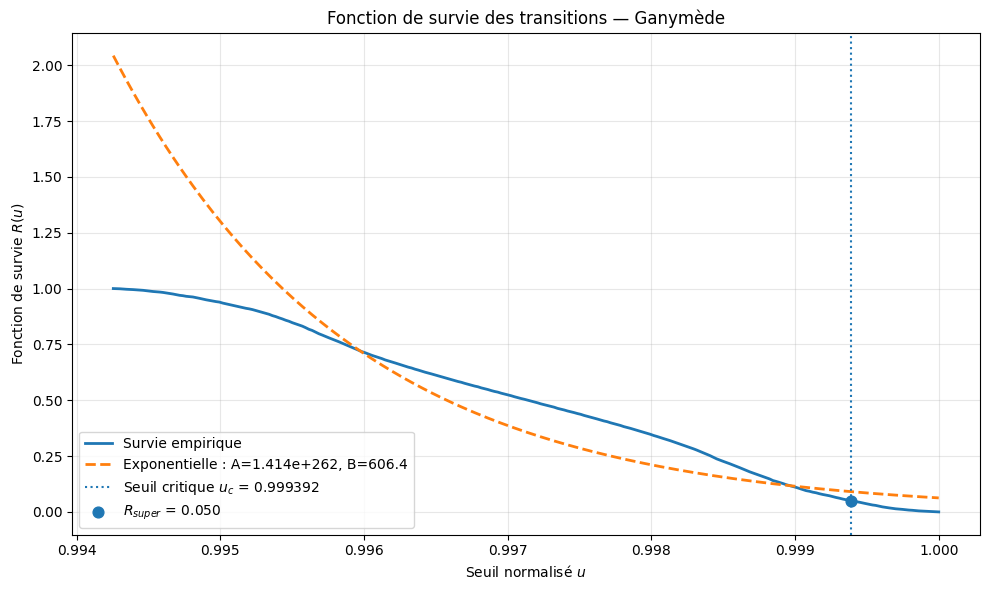


A_H                         : 1.41403843794e+262
B_H                         : 606.393608625
R² exponentiel              : 0.525922475
RMSE exponentiel            : 0.208447122
MAE exponentiel             : 0.141047098
R_empirique(u_c)             : 0.050000000
R_exponentielle(u_c)         : 0.090616326
Écart au seuil critique      : 0.040616326

Analyse de survie exécutée et contrôles validés.


In [7]:
# ============================================================
# 8. Fonction de survie et ajustement exponentiel — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

print("=" * 90)
print("FONCTION DE SURVIE ET AJUSTEMENT EXPONENTIEL — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Données normalisées
# ------------------------------------------------------------

u_values = ganymede["u"].to_numpy(dtype=float)

if (
    len(u_values) == 0
    or not np.isfinite(u_values).all()
    or np.any(u_values <= 0)
):
    raise ValueError("Les valeurs de u sont invalides.")

N_transition = len(u_values)

# ------------------------------------------------------------
# 2. Grille régulière de seuils
# ------------------------------------------------------------

n_seuils = 250

u_seuils = np.linspace(
    float(u_values.min()),
    float(u_values.max()),
    n_seuils
)

# Fonction de survie empirique :
# proportion des transitions telles que u_i > seuil
R_empirique = np.array([
    np.mean(u_values > seuil)
    for seuil in u_seuils
], dtype=float)

survie_ganymede = pd.DataFrame({
    "u_seuil": u_seuils,
    "R_empirique": R_empirique
})

# ------------------------------------------------------------
# 3. Domaine d'ajustement
# ------------------------------------------------------------
# On retire les extrémités R=0 et R=1, qui ne sont pas
# exploitables dans un ajustement logarithmique/exponentiel.
# On conserve la partie intermédiaire de la survie.

masque_fit = (
    np.isfinite(u_seuils)
    & np.isfinite(R_empirique)
    & (R_empirique > 0.01)
    & (R_empirique < 0.99)
)

u_fit = u_seuils[masque_fit]
R_fit = R_empirique[masque_fit]

if len(u_fit) < 10:
    raise ValueError(
        "Nombre insuffisant de points pour l'ajustement exponentiel."
    )

# ------------------------------------------------------------
# 4. Modèle exponentiel
# ------------------------------------------------------------

def modele_exponentiel(u, A_H, B_H):
    return A_H * np.exp(-B_H * u)

# Estimation initiale par régression sur log(R)
pente_initiale, intercept_initial = np.polyfit(
    u_fit,
    np.log(R_fit),
    1
)

A_initial = float(np.exp(intercept_initial))
B_initial = float(max(-pente_initiale, 1e-12))

# Ajustement non linéaire
try:
    parametres_exp, covariance_exp = curve_fit(
        modele_exponentiel,
        u_fit,
        R_fit,
        p0=[A_initial, B_initial],
        bounds=([0.0, 0.0], [np.inf, np.inf]),
        maxfev=100000
    )

    A_H = float(parametres_exp[0])
    B_H = float(parametres_exp[1])

except Exception as erreur:
    print("\nAjustement non linéaire impossible.")
    print("Utilisation de l'estimation logarithmique initiale.")
    print("Erreur :", erreur)

    A_H = A_initial
    B_H = B_initial

# ------------------------------------------------------------
# 5. Prédictions
# ------------------------------------------------------------

R_exp_fit = modele_exponentiel(
    u_fit,
    A_H,
    B_H
)

R_exp_complet = modele_exponentiel(
    u_seuils,
    A_H,
    B_H
)

survie_ganymede["R_exponentielle"] = R_exp_complet
survie_ganymede["Utilise_pour_fit"] = masque_fit

# ------------------------------------------------------------
# 6. Métriques d'ajustement
# ------------------------------------------------------------

residus_exp = R_fit - R_exp_fit

SSE_H = float(np.sum(residus_exp**2))
RMSE_H = float(np.sqrt(np.mean(residus_exp**2)))
MAE_H = float(np.mean(np.abs(residus_exp)))

SST_H = float(
    np.sum((R_fit - np.mean(R_fit))**2)
)

R2_H = (
    float(1.0 - SSE_H / SST_H)
    if SST_H > 0
    else np.nan
)

n_fit = len(R_fit)
k_exp = 2

AIC_H = (
    float(
        n_fit * np.log(SSE_H / n_fit)
        + 2 * k_exp
    )
    if SSE_H > 0
    else -np.inf
)

BIC_H = (
    float(
        n_fit * np.log(SSE_H / n_fit)
        + k_exp * np.log(n_fit)
    )
    if SSE_H > 0
    else -np.inf
)

# ------------------------------------------------------------
# 7. Valeur du modèle au seuil critique
# ------------------------------------------------------------

R_modele_uc = float(
    modele_exponentiel(u_c, A_H, B_H)
)

erreur_uc = float(
    R_modele_uc - R_super
)

# ------------------------------------------------------------
# 8. Tableau récapitulatif
# ------------------------------------------------------------

resume_survie_ganymede = pd.DataFrame({
    "Observable": [
        "Nombre de seuils",
        "Nombre de points ajustés",
        "u_fit_min",
        "u_fit_max",
        "A_H",
        "B_H",
        "R2_H",
        "RMSE_H",
        "MAE_H",
        "AIC_H",
        "BIC_H",
        "R_super empirique à u_c",
        "R exponentielle à u_c",
        "Erreur au seuil u_c"
    ],
    "Valeur": [
        len(u_seuils),
        n_fit,
        float(u_fit.min()),
        float(u_fit.max()),
        A_H,
        B_H,
        R2_H,
        RMSE_H,
        MAE_H,
        AIC_H,
        BIC_H,
        R_super,
        R_modele_uc,
        erreur_uc
    ]
})

display(resume_survie_ganymede)

# ------------------------------------------------------------
# 9. Contrôles
# ------------------------------------------------------------

survie_decroissante = bool(
    np.all(np.diff(R_empirique) <= 1e-12)
)

controle_survie_ganymede = pd.DataFrame({
    "Contrôle": [
        "Survie sans NaN",
        "Survie comprise entre 0 et 1",
        "Survie monotone décroissante",
        "Nombre suffisant de points ajustés",
        "A_H strictement positif",
        "B_H strictement positif",
        "R² fini",
        "RMSE fini",
        "Prédiction à u_c comprise entre 0 et 1"
    ],
    "Résultat": [
        bool(np.isfinite(R_empirique).all()),
        bool(
            (R_empirique >= 0).all()
            and (R_empirique <= 1).all()
        ),
        survie_decroissante,
        n_fit >= 10,
        A_H > 0,
        B_H > 0,
        bool(np.isfinite(R2_H)),
        bool(np.isfinite(RMSE_H)),
        0.0 <= R_modele_uc <= 1.0
    ]
})

display(controle_survie_ganymede)

# ------------------------------------------------------------
# 10. Graphique
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    u_seuils,
    R_empirique,
    label="Survie empirique",
    linewidth=2
)

plt.plot(
    u_seuils,
    R_exp_complet,
    "--",
    label=(
        f"Exponentielle : "
        f"A={A_H:.4g}, B={B_H:.4g}"
    ),
    linewidth=2
)

plt.axvline(
    u_c,
    linestyle=":",
    label=f"Seuil critique $u_c$ = {u_c:.6f}"
)

plt.scatter(
    [u_c],
    [R_super],
    s=60,
    zorder=5,
    label=f"$R_{{super}}$ = {R_super:.3f}"
)

plt.xlabel("Seuil normalisé $u$")
plt.ylabel("Fonction de survie $R(u)$")
plt.title(
    "Fonction de survie des transitions — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Résumé textuel
# ------------------------------------------------------------

print(f"\nA_H                         : {A_H:.12g}")
print(f"B_H                         : {B_H:.12g}")
print(f"R² exponentiel              : {R2_H:.9f}")
print(f"RMSE exponentiel            : {RMSE_H:.9f}")
print(f"MAE exponentiel             : {MAE_H:.9f}")
print(f"R_empirique(u_c)             : {R_super:.9f}")
print(f"R_exponentielle(u_c)         : {R_modele_uc:.9f}")
print(f"Écart au seuil critique      : {erreur_uc:.9f}")

if controle_survie_ganymede["Résultat"].all():
    print("\nAnalyse de survie exécutée et contrôles validés.")
else:
    print("\nAttention : au moins un contrôle de survie a échoué.")

AJUSTEMENT EXPONENTIEL STABILISÉ — GANYMÈDE


,Observable,Valeur
0,u_reference,0.994508
1,C_H,1.148948
2,B_H_centre,365.661289
3,log(A_H_equivalent),363.792012
4,log10(A_H_equivalent),157.992863
5,R2_H_centre,0.936317
6,RMSE_H_centre,0.076398
7,MAE_H_centre,0.064954
8,AIC_H_centre,-1168.740949
9,BIC_H_centre,-1161.882258


,Contrôle,Résultat
0,C_H fini et positif,True
1,B_H fini et positif,True
2,Prédictions finies,True
3,Prédictions positives,True
4,R² fini,True
5,RMSE fini,True
6,Équivalence avec le fit brut,False


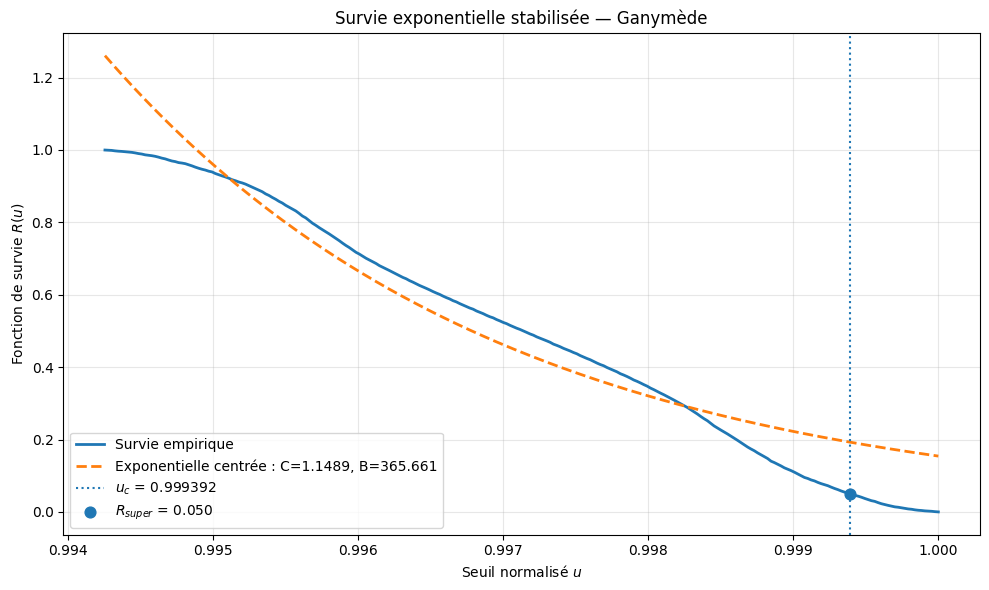


Référence u₀                  : 0.994508238990
C_H                           : 1.14894828579
B_H centré                    : 365.661289007
log10(A_H équivalent)         : 157.992863
R²                            : 0.936317489
RMSE                          : 0.076397880
R modèle au seuil             : 0.192642064
Erreur au seuil               : 0.142642064

Attention : au moins un contrôle a échoué.


In [8]:
# ============================================================
# 8B. Ajustement exponentiel stabilisé — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

print("=" * 90)
print("AJUSTEMENT EXPONENTIEL STABILISÉ — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Variable centrée
# ------------------------------------------------------------

u_reference = float(u_fit.min())

x_fit = u_fit - u_reference
x_complet = u_seuils - u_reference

# ------------------------------------------------------------
# 2. Modèle exponentiel centré
# ------------------------------------------------------------

def modele_exp_centre(x, C_H, B_H_centre):
    return C_H * np.exp(-B_H_centre * x)

# Estimation initiale logarithmique
pente_init, intercept_init = np.polyfit(
    x_fit,
    np.log(R_fit),
    1
)

C_initial = float(np.exp(intercept_init))
B_initial_centre = float(max(-pente_init, 1e-12))

# ------------------------------------------------------------
# 3. Ajustement
# ------------------------------------------------------------

parametres_centres, covariance_centree = curve_fit(
    modele_exp_centre,
    x_fit,
    R_fit,
    p0=[C_initial, B_initial_centre],
    bounds=([0.0, 0.0], [2.0, np.inf]),
    maxfev=100000
)

C_H = float(parametres_centres[0])
B_H_centre = float(parametres_centres[1])

# ------------------------------------------------------------
# 4. Prédictions
# ------------------------------------------------------------

R_exp_centre_fit = modele_exp_centre(
    x_fit,
    C_H,
    B_H_centre
)

R_exp_centre_complet = modele_exp_centre(
    x_complet,
    C_H,
    B_H_centre
)

# ------------------------------------------------------------
# 5. Métriques
# ------------------------------------------------------------

residus_centres = R_fit - R_exp_centre_fit

SSE_H_centre = float(np.sum(residus_centres**2))
RMSE_H_centre = float(np.sqrt(np.mean(residus_centres**2)))
MAE_H_centre = float(np.mean(np.abs(residus_centres)))

SST_H_centre = float(
    np.sum((R_fit - np.mean(R_fit))**2)
)

R2_H_centre = float(
    1.0 - SSE_H_centre / SST_H_centre
)

n_centre = len(R_fit)
k_centre = 2

AIC_H_centre = float(
    n_centre * np.log(SSE_H_centre / n_centre)
    + 2 * k_centre
)

BIC_H_centre = float(
    n_centre * np.log(SSE_H_centre / n_centre)
    + k_centre * np.log(n_centre)
)

# ------------------------------------------------------------
# 6. Valeur au seuil critique
# ------------------------------------------------------------

x_c = u_c - u_reference

R_centre_uc = float(
    modele_exp_centre(
        x_c,
        C_H,
        B_H_centre
    )
)

erreur_centre_uc = float(
    R_centre_uc - R_super
)

# ------------------------------------------------------------
# 7. Équivalence avec la forme brute
# ------------------------------------------------------------
# A_H = C_H * exp(B_H * u_reference)
# On conserve log(A_H), car A_H peut dépasser la capacité
# numérique des nombres flottants.

log_A_H_equivalent = float(
    np.log(C_H)
    + B_H_centre * u_reference
)

log10_A_H_equivalent = float(
    log_A_H_equivalent / np.log(10.0)
)

# ------------------------------------------------------------
# 8. Tableau récapitulatif
# ------------------------------------------------------------

resume_exp_stabilise_ganymede = pd.DataFrame({
    "Observable": [
        "u_reference",
        "C_H",
        "B_H_centre",
        "log(A_H_equivalent)",
        "log10(A_H_equivalent)",
        "R2_H_centre",
        "RMSE_H_centre",
        "MAE_H_centre",
        "AIC_H_centre",
        "BIC_H_centre",
        "R_empirique(u_c)",
        "R_modele_centre(u_c)",
        "Erreur_modele(u_c)"
    ],
    "Valeur": [
        u_reference,
        C_H,
        B_H_centre,
        log_A_H_equivalent,
        log10_A_H_equivalent,
        R2_H_centre,
        RMSE_H_centre,
        MAE_H_centre,
        AIC_H_centre,
        BIC_H_centre,
        R_super,
        R_centre_uc,
        erreur_centre_uc
    ]
})

display(resume_exp_stabilise_ganymede)

# ------------------------------------------------------------
# 9. Contrôles
# ------------------------------------------------------------

controle_exp_stabilise = pd.DataFrame({
    "Contrôle": [
        "C_H fini et positif",
        "B_H fini et positif",
        "Prédictions finies",
        "Prédictions positives",
        "R² fini",
        "RMSE fini",
        "Équivalence avec le fit brut"
    ],
    "Résultat": [
        np.isfinite(C_H) and C_H > 0,
        np.isfinite(B_H_centre) and B_H_centre > 0,
        np.isfinite(R_exp_centre_complet).all(),
        (R_exp_centre_complet >= 0).all(),
        np.isfinite(R2_H_centre),
        np.isfinite(RMSE_H_centre),
        np.isclose(R2_H_centre, R2_H, atol=1e-6)
    ]
})

display(controle_exp_stabilise)

# ------------------------------------------------------------
# 10. Enregistrement pour les exports
# ------------------------------------------------------------

survie_ganymede["R_exponentielle_stabilisee"] = (
    R_exp_centre_complet
)

# ------------------------------------------------------------
# 11. Graphique
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    u_seuils,
    R_empirique,
    linewidth=2,
    label="Survie empirique"
)

plt.plot(
    u_seuils,
    R_exp_centre_complet,
    "--",
    linewidth=2,
    label=(
        f"Exponentielle centrée : "
        f"C={C_H:.4f}, B={B_H_centre:.3f}"
    )
)

plt.axvline(
    u_c,
    linestyle=":",
    label=f"$u_c$ = {u_c:.6f}"
)

plt.scatter(
    [u_c],
    [R_super],
    s=60,
    zorder=5,
    label=f"$R_{{super}}$ = {R_super:.3f}"
)

plt.xlabel("Seuil normalisé $u$")
plt.ylabel("Fonction de survie $R(u)$")
plt.title(
    "Survie exponentielle stabilisée — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nRéférence u₀                  : {u_reference:.12f}")
print(f"C_H                           : {C_H:.12g}")
print(f"B_H centré                    : {B_H_centre:.12g}")
print(f"log10(A_H équivalent)         : {log10_A_H_equivalent:.6f}")
print(f"R²                            : {R2_H_centre:.9f}")
print(f"RMSE                          : {RMSE_H_centre:.9f}")
print(f"R modèle au seuil             : {R_centre_uc:.9f}")
print(f"Erreur au seuil               : {erreur_centre_uc:.9f}")

if controle_exp_stabilise["Résultat"].all():
    print("\nAjustement exponentiel stabilisé exécuté correctement.")
else:
    print("\nAttention : au moins un contrôle a échoué.")

PRÉPARATION DU DOMAINE COMMUN — GANYMÈDE


,Contrôle,Résultat
0,Nombre de seuils conservé,True
1,x sans NaN ou infini,True
2,R sans NaN ou infini,True
3,x compris entre 0 et 1,True
4,R_fit compris entre 0 et 1,True
5,Même nombre de x_fit et R_fit,True
6,Nombre suffisant de points,True
7,x_fit strictement croissant,True


,Paramètre,Valeur
0,u_min,0.994254
1,u_max,1.000000
2,Amplitude de u,0.005746
3,x_min,0.000000
4,x_max,1.000000
5,x_fit_min,0.044177
6,x_fit_max,0.955823
7,Nombre total de seuils,250.000000
8,Nombre de points ajustés,228.000000
9,R_fit_min,0.011416


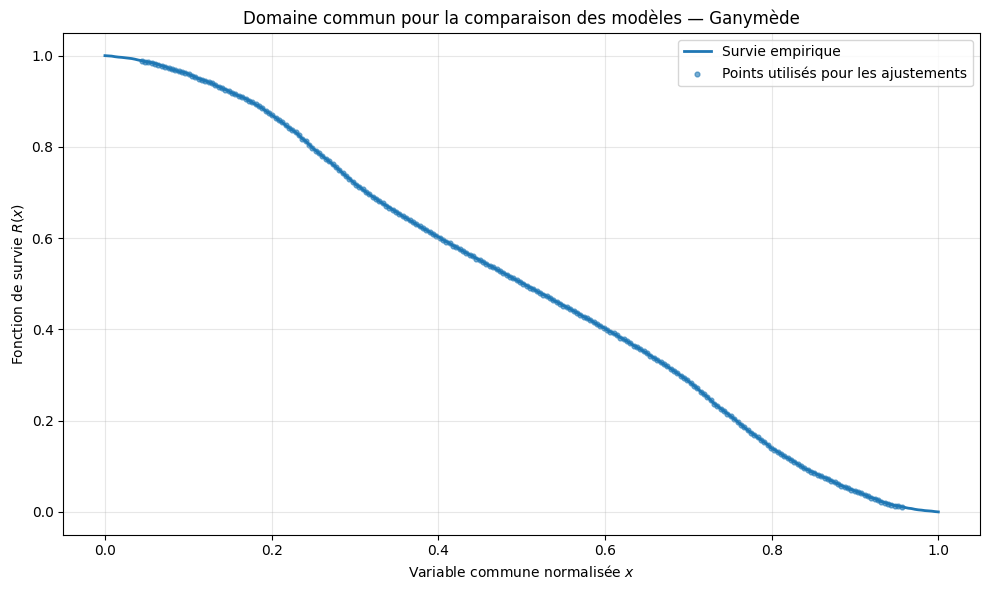


u minimum original         : 0.994254418103
u maximum original         : 1.000000000000
Amplitude de u             : 0.005745581897
x minimum                  : 0.000000
x maximum                  : 1.000000
Points utilisés pour fit   : 228

Domaine commun validé.
Les modèles exponentiel, Weibull, logistique et Gompertz pourront maintenant être comparés sur les mêmes points.


In [9]:
# ============================================================
# 8C. Préparation du domaine commun pour comparaison des modèles
#     Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("PRÉPARATION DU DOMAINE COMMUN — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Vérification des variables issues de la cellule précédente
# ------------------------------------------------------------

variables_requises = [
    "u_seuils",
    "R_empirique",
    "masque_fit"
]

variables_absentes = [
    nom for nom in variables_requises
    if nom not in globals()
]

if variables_absentes:
    raise NameError(
        "Variables manquantes : "
        + ", ".join(variables_absentes)
        + ". Exécuter d'abord la cellule de survie."
    )

# ------------------------------------------------------------
# 2. Conversion en tableaux numériques
# ------------------------------------------------------------

u_modele = np.asarray(
    u_seuils,
    dtype=float
)

R_modele = np.asarray(
    R_empirique,
    dtype=float
)

masque_modele = np.asarray(
    masque_fit,
    dtype=bool
)

# ------------------------------------------------------------
# 3. Bornes du domaine
# ------------------------------------------------------------

u_min_modele = float(
    np.min(u_modele)
)

u_max_modele = float(
    np.max(u_modele)
)

amplitude_u = float(
    u_max_modele - u_min_modele
)

if not np.isfinite(amplitude_u) or amplitude_u <= 0:
    raise ValueError(
        "Le domaine de u est invalide ou de largeur nulle."
    )

# ------------------------------------------------------------
# 4. Variable commune normalisée x dans [0,1]
# ------------------------------------------------------------

x_modele = (
    u_modele - u_min_modele
) / amplitude_u

# Données utilisées pour tous les ajustements
x_fit_commun = x_modele[masque_modele]
R_fit_commun = R_modele[masque_modele]

u_fit_commun = u_modele[masque_modele]

# ------------------------------------------------------------
# 5. Vérifications
# ------------------------------------------------------------

controle_domaine_commun = pd.DataFrame({
    "Contrôle": [
        "Nombre de seuils conservé",
        "x sans NaN ou infini",
        "R sans NaN ou infini",
        "x compris entre 0 et 1",
        "R_fit compris entre 0 et 1",
        "Même nombre de x_fit et R_fit",
        "Nombre suffisant de points",
        "x_fit strictement croissant"
    ],
    "Résultat": [
        len(x_modele) == len(u_modele),
        bool(np.isfinite(x_modele).all()),
        bool(np.isfinite(R_modele).all()),
        bool(
            (x_modele >= -1e-12).all()
            and (x_modele <= 1.0 + 1e-12).all()
        ),
        bool(
            (R_fit_commun > 0).all()
            and (R_fit_commun < 1).all()
        ),
        len(x_fit_commun) == len(R_fit_commun),
        len(x_fit_commun) >= 10,
        bool(np.all(np.diff(x_fit_commun) > 0))
    ]
})

display(controle_domaine_commun)

# ------------------------------------------------------------
# 6. Tableau récapitulatif
# ------------------------------------------------------------

resume_domaine_commun = pd.DataFrame({
    "Paramètre": [
        "u_min",
        "u_max",
        "Amplitude de u",
        "x_min",
        "x_max",
        "x_fit_min",
        "x_fit_max",
        "Nombre total de seuils",
        "Nombre de points ajustés",
        "R_fit_min",
        "R_fit_max"
    ],
    "Valeur": [
        u_min_modele,
        u_max_modele,
        amplitude_u,
        float(np.min(x_modele)),
        float(np.max(x_modele)),
        float(np.min(x_fit_commun)),
        float(np.max(x_fit_commun)),
        len(x_modele),
        len(x_fit_commun),
        float(np.min(R_fit_commun)),
        float(np.max(R_fit_commun))
    ]
})

display(resume_domaine_commun)

# ------------------------------------------------------------
# 7. DataFrame commun
# ------------------------------------------------------------

comparaison_modeles_ganymede = pd.DataFrame({
    "u_seuil": u_modele,
    "x_normalise": x_modele,
    "R_empirique": R_modele,
    "Utilise_pour_fit": masque_modele
})

# ------------------------------------------------------------
# 8. Graphique de vérification
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    x_modele,
    R_modele,
    linewidth=2,
    label="Survie empirique"
)

plt.scatter(
    x_fit_commun,
    R_fit_commun,
    s=12,
    alpha=0.6,
    label="Points utilisés pour les ajustements"
)

plt.xlabel("Variable commune normalisée $x$")
plt.ylabel("Fonction de survie $R(x)$")
plt.title(
    "Domaine commun pour la comparaison des modèles — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Résumé textuel
# ------------------------------------------------------------

print(f"\nu minimum original         : {u_min_modele:.12f}")
print(f"u maximum original         : {u_max_modele:.12f}")
print(f"Amplitude de u             : {amplitude_u:.12f}")
print(f"x minimum                  : {x_modele.min():.6f}")
print(f"x maximum                  : {x_modele.max():.6f}")
print(f"Points utilisés pour fit   : {len(x_fit_commun)}")

if controle_domaine_commun["Résultat"].all():
    print("\nDomaine commun validé.")
    print(
        "Les modèles exponentiel, Weibull, logistique et Gompertz "
        "pourront maintenant être comparés sur les mêmes points."
    )
else:
    print("\nAttention : au moins un contrôle du domaine commun a échoué.")

AJUSTEMENT WEIBULL — GANYMÈDE


,Observable,Valeur
0,lambda,0.588709
1,k,1.889647
2,R2,0.987379
3,RMSE,0.034011
4,MAE,0.028067
5,AIC,-1537.764041
6,BIC,-1530.905349
7,R(u_c),0.110478
8,Erreur(u_c),0.060478


,Contrôle,Résultat
0,lambda >0,True
1,k >0,True
2,R² fini,True
3,RMSE fini,True
4,Prédictions positives,True
5,Prédictions <=1,True


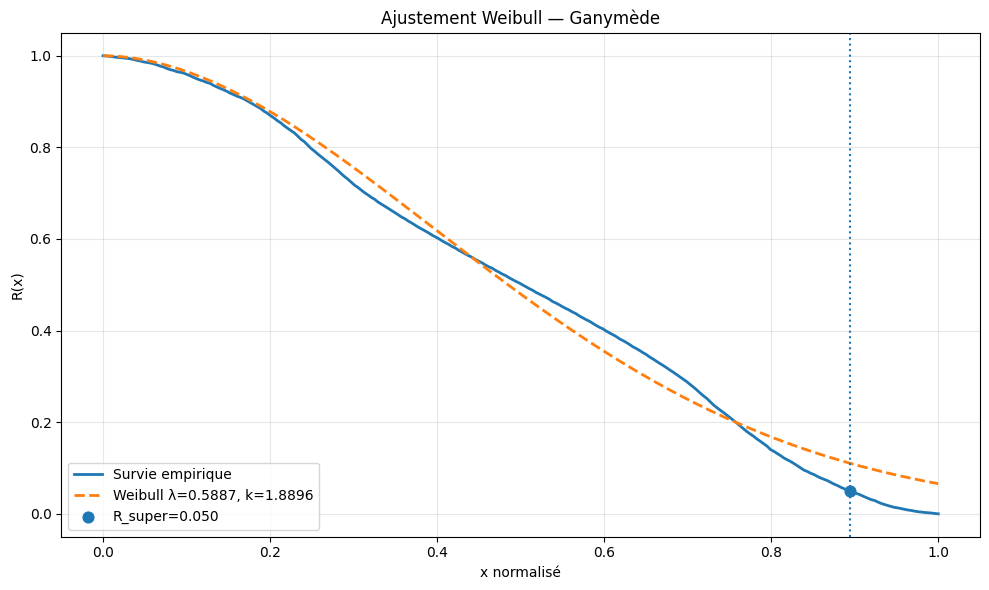


λ                 : 0.588708540590
k                 : 1.889647214528
R²                : 0.987378678
RMSE              : 0.034011333
MAE               : 0.028066765
AIC               : -1537.764041
BIC               : -1530.905349
R(u_c)            : 0.110478112
Erreur(u_c)       : 0.060478112

Ajustement Weibull validé.


In [10]:
# ============================================================
# 9. Ajustement Weibull — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

print("=" * 90)
print("AJUSTEMENT WEIBULL — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Modèle Weibull
# ------------------------------------------------------------

def modele_weibull(x, lambda_W, k_W):
    x = np.maximum(x, 1e-12)
    return np.exp(- (x / lambda_W) ** k_W)

# ------------------------------------------------------------
# 2. Estimation initiale
# ------------------------------------------------------------

lambda_init = 0.50
k_init = 1.50

param_weibull, cov_weibull = curve_fit(
    modele_weibull,
    x_fit_commun,
    R_fit_commun,
    p0=[lambda_init, k_init],
    bounds=([1e-6,1e-6],[10,20]),
    maxfev=100000
)

lambda_W = float(param_weibull[0])
k_W = float(param_weibull[1])

# ------------------------------------------------------------
# 3. Prédictions
# ------------------------------------------------------------

R_weibull_fit = modele_weibull(
    x_fit_commun,
    lambda_W,
    k_W
)

R_weibull = modele_weibull(
    x_modele,
    lambda_W,
    k_W
)

comparaison_modeles_ganymede[
    "R_weibull"
] = R_weibull

# ------------------------------------------------------------
# 4. Statistiques
# ------------------------------------------------------------

residus = R_fit_commun - R_weibull_fit

SSE = float(np.sum(residus**2))
RMSE = float(np.sqrt(np.mean(residus**2)))
MAE = float(np.mean(np.abs(residus)))

SST = float(
    np.sum(
        (R_fit_commun - np.mean(R_fit_commun))**2
    )
)

R2 = float(
    1.0 - SSE/SST
)

n = len(R_fit_commun)
p = 2

AIC = float(
    n*np.log(SSE/n)+2*p
)

BIC = float(
    n*np.log(SSE/n)+p*np.log(n)
)

# ------------------------------------------------------------
# 5. Valeur au seuil critique
# ------------------------------------------------------------

x_uc = (u_c-u_min_modele)/amplitude_u

R_uc = float(
    modele_weibull(
        x_uc,
        lambda_W,
        k_W
    )
)

Erreur_uc = float(
    R_uc-R_super
)

# ------------------------------------------------------------
# 6. Résumé
# ------------------------------------------------------------

resume_weibull = pd.DataFrame({

"Observable":[
"lambda",
"k",
"R2",
"RMSE",
"MAE",
"AIC",
"BIC",
"R(u_c)",
"Erreur(u_c)"
],

"Valeur":[
lambda_W,
k_W,
R2,
RMSE,
MAE,
AIC,
BIC,
R_uc,
Erreur_uc
]

})

display(resume_weibull)

# ------------------------------------------------------------
# 7. Contrôles
# ------------------------------------------------------------

controle_weibull = pd.DataFrame({

"Contrôle":[
"lambda >0",
"k >0",
"R² fini",
"RMSE fini",
"Prédictions positives",
"Prédictions <=1"
],

"Résultat":[
lambda_W>0,
k_W>0,
np.isfinite(R2),
np.isfinite(RMSE),
(R_weibull>=0).all(),
(R_weibull<=1).all()
]

})

display(controle_weibull)

# ------------------------------------------------------------
# 8. Graphique
# ------------------------------------------------------------

plt.figure(figsize=(10,6))

plt.plot(
    x_modele,
    R_modele,
    lw=2,
    label="Survie empirique"
)

plt.plot(
    x_modele,
    R_weibull,
    "--",
    lw=2,
    label=f"Weibull λ={lambda_W:.4f}, k={k_W:.4f}"
)

plt.scatter(
    [x_uc],
    [R_super],
    s=60,
    zorder=5,
    label=f"R_super={R_super:.3f}"
)

plt.axvline(
    x_uc,
    linestyle=":"
)

plt.xlabel("x normalisé")
plt.ylabel("R(x)")
plt.title("Ajustement Weibull — Ganymède")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

plt.show()

# ------------------------------------------------------------
# 9. Résumé texte
# ------------------------------------------------------------

print(f"\nλ                 : {lambda_W:.12f}")
print(f"k                 : {k_W:.12f}")
print(f"R²                : {R2:.9f}")
print(f"RMSE              : {RMSE:.9f}")
print(f"MAE               : {MAE:.9f}")
print(f"AIC               : {AIC:.6f}")
print(f"BIC               : {BIC:.6f}")
print(f"R(u_c)            : {R_uc:.9f}")
print(f"Erreur(u_c)       : {Erreur_uc:.9f}")

if controle_weibull["Résultat"].all():
    print("\nAjustement Weibull validé.")
else:
    print("\nAttention : un contrôle Weibull a échoué.")

AJUSTEMENT LOGISTIQUE — GANYMÈDE


,Observable,Valeur
0,x0,0.502557
1,k,5.725414
2,R2,0.985341
3,RMSE,0.036655
4,MAE,0.033035
5,AIC,-1503.633578
6,BIC,-1496.774887
7,R(u_c),0.096032
8,Erreur signée (u_c),0.046032
9,Erreur absolue (u_c),0.046032


,Contrôle,Résultat
0,x0 fini,True
1,k strictement positif,True
2,R² fini,True
3,RMSE fini,True
4,Prédictions finies,True
5,Prédictions comprises entre 0 et 1,True
6,Courbe monotone décroissante,True
7,Valeur au seuil comprise entre 0 et 1,True


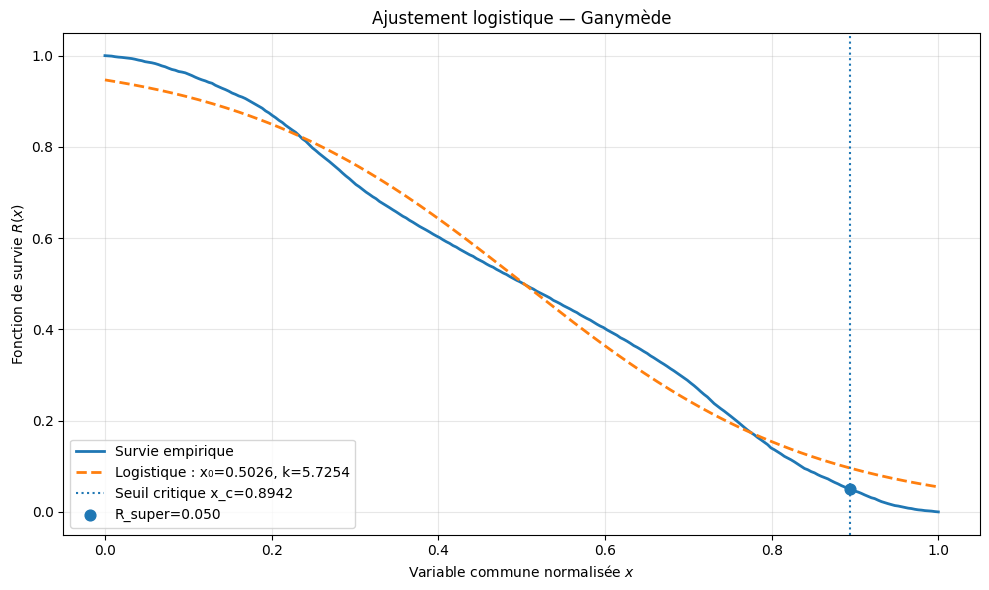


x₀                        : 0.502557103066
k logistique              : 5.725414399746
R²                        : 0.985340587
RMSE                      : 0.036654686
MAE                       : 0.033034631
AIC                       : -1503.633578
BIC                       : -1496.774887
R_logistique(u_c)         : 0.096032362
Erreur signée au seuil    : 0.046032362
Erreur absolue au seuil   : 0.046032362

Ajustement logistique validé.


In [11]:
# ============================================================
# 10. Ajustement logistique — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

print("=" * 90)
print("AJUSTEMENT LOGISTIQUE — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Modèle logistique décroissant
# ------------------------------------------------------------

def modele_logistique(x, x0_L, k_L):
    argument = np.clip(
        k_L * (x - x0_L),
        -700,
        700
    )

    return 1.0 / (1.0 + np.exp(argument))

# ------------------------------------------------------------
# 2. Estimations initiales
# ------------------------------------------------------------

# Point empirique le plus proche de R = 0,5
indice_median = int(
    np.argmin(np.abs(R_fit_commun - 0.5))
)

x0_initial = float(
    x_fit_commun[indice_median]
)

k_initial = 8.0

# ------------------------------------------------------------
# 3. Ajustement non linéaire
# ------------------------------------------------------------

param_logistique, cov_logistique = curve_fit(
    modele_logistique,
    x_fit_commun,
    R_fit_commun,
    p0=[x0_initial, k_initial],
    bounds=(
        [-1.0, 1e-8],
        [2.0, 1000.0]
    ),
    maxfev=100000
)

x0_L = float(param_logistique[0])
k_L = float(param_logistique[1])

# ------------------------------------------------------------
# 4. Prédictions
# ------------------------------------------------------------

R_logistique_fit = modele_logistique(
    x_fit_commun,
    x0_L,
    k_L
)

R_logistique = modele_logistique(
    x_modele,
    x0_L,
    k_L
)

comparaison_modeles_ganymede[
    "R_logistique"
] = R_logistique

# ------------------------------------------------------------
# 5. Métriques
# ------------------------------------------------------------

residus_logistique = (
    R_fit_commun - R_logistique_fit
)

SSE_logistique = float(
    np.sum(residus_logistique**2)
)

RMSE_logistique = float(
    np.sqrt(
        np.mean(residus_logistique**2)
    )
)

MAE_logistique = float(
    np.mean(
        np.abs(residus_logistique)
    )
)

SST_commun = float(
    np.sum(
        (
            R_fit_commun
            - np.mean(R_fit_commun)
        )**2
    )
)

R2_logistique = float(
    1.0 - SSE_logistique / SST_commun
)

n_logistique = len(R_fit_commun)
p_logistique = 2

AIC_logistique = float(
    n_logistique
    * np.log(SSE_logistique / n_logistique)
    + 2 * p_logistique
)

BIC_logistique = float(
    n_logistique
    * np.log(SSE_logistique / n_logistique)
    + p_logistique * np.log(n_logistique)
)

# ------------------------------------------------------------
# 6. Valeur au seuil critique
# ------------------------------------------------------------

x_uc = float(
    (u_c - u_min_modele) / amplitude_u
)

R_logistique_uc = float(
    modele_logistique(
        x_uc,
        x0_L,
        k_L
    )
)

Erreur_logistique_uc = float(
    R_logistique_uc - R_super
)

Erreur_absolue_logistique_uc = float(
    abs(Erreur_logistique_uc)
)

# ------------------------------------------------------------
# 7. Tableau récapitulatif
# ------------------------------------------------------------

resume_logistique = pd.DataFrame({
    "Observable": [
        "x0",
        "k",
        "R2",
        "RMSE",
        "MAE",
        "AIC",
        "BIC",
        "R(u_c)",
        "Erreur signée (u_c)",
        "Erreur absolue (u_c)"
    ],
    "Valeur": [
        x0_L,
        k_L,
        R2_logistique,
        RMSE_logistique,
        MAE_logistique,
        AIC_logistique,
        BIC_logistique,
        R_logistique_uc,
        Erreur_logistique_uc,
        Erreur_absolue_logistique_uc
    ]
})

display(resume_logistique)

# ------------------------------------------------------------
# 8. Contrôles
# ------------------------------------------------------------

controle_logistique = pd.DataFrame({
    "Contrôle": [
        "x0 fini",
        "k strictement positif",
        "R² fini",
        "RMSE fini",
        "Prédictions finies",
        "Prédictions comprises entre 0 et 1",
        "Courbe monotone décroissante",
        "Valeur au seuil comprise entre 0 et 1"
    ],
    "Résultat": [
        bool(np.isfinite(x0_L)),
        bool(np.isfinite(k_L) and k_L > 0),
        bool(np.isfinite(R2_logistique)),
        bool(np.isfinite(RMSE_logistique)),
        bool(np.isfinite(R_logistique).all()),
        bool(
            (R_logistique >= 0).all()
            and (R_logistique <= 1).all()
        ),
        bool(
            np.all(
                np.diff(R_logistique) <= 1e-12
            )
        ),
        bool(
            0.0 <= R_logistique_uc <= 1.0
        )
    ]
})

display(controle_logistique)

# ------------------------------------------------------------
# 9. Graphique
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    x_modele,
    R_modele,
    linewidth=2,
    label="Survie empirique"
)

plt.plot(
    x_modele,
    R_logistique,
    "--",
    linewidth=2,
    label=(
        f"Logistique : "
        f"x₀={x0_L:.4f}, k={k_L:.4f}"
    )
)

plt.axvline(
    x_uc,
    linestyle=":",
    label=f"Seuil critique x_c={x_uc:.4f}"
)

plt.scatter(
    [x_uc],
    [R_super],
    s=60,
    zorder=5,
    label=f"R_super={R_super:.3f}"
)

plt.xlabel("Variable commune normalisée $x$")
plt.ylabel("Fonction de survie $R(x)$")
plt.title(
    "Ajustement logistique — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Résumé textuel
# ------------------------------------------------------------

print(f"\nx₀                        : {x0_L:.12f}")
print(f"k logistique              : {k_L:.12f}")
print(f"R²                        : {R2_logistique:.9f}")
print(f"RMSE                      : {RMSE_logistique:.9f}")
print(f"MAE                       : {MAE_logistique:.9f}")
print(f"AIC                       : {AIC_logistique:.6f}")
print(f"BIC                       : {BIC_logistique:.6f}")
print(f"R_logistique(u_c)         : {R_logistique_uc:.9f}")
print(f"Erreur signée au seuil    : {Erreur_logistique_uc:.9f}")
print(f"Erreur absolue au seuil   : {Erreur_absolue_logistique_uc:.9f}")

if controle_logistique["Résultat"].all():
    print("\nAjustement logistique validé.")
else:
    print("\nAttention : au moins un contrôle logistique a échoué.")

AJUSTEMENT GOMPERTZ — GANYMÈDE


,Observable,Valeur
0,a,0.215685
1,b,2.849599
2,R2,0.993435
3,RMSE,0.024529
4,MAE,0.022383
5,AIC,-1686.796276
6,BIC,-1679.937585
7,R(u_c),0.078778
8,Erreur signée (u_c),0.028778
9,Erreur absolue (u_c),0.028778


,Contrôle,Résultat
0,a strictement positif,True
1,b strictement positif,True
2,R² fini,True
3,RMSE fini,True
4,Prédictions finies,True
5,Prédictions comprises entre 0 et 1,True
6,Courbe monotone décroissante,True
7,R(0) égal à 1,True
8,Valeur au seuil comprise entre 0 et 1,True


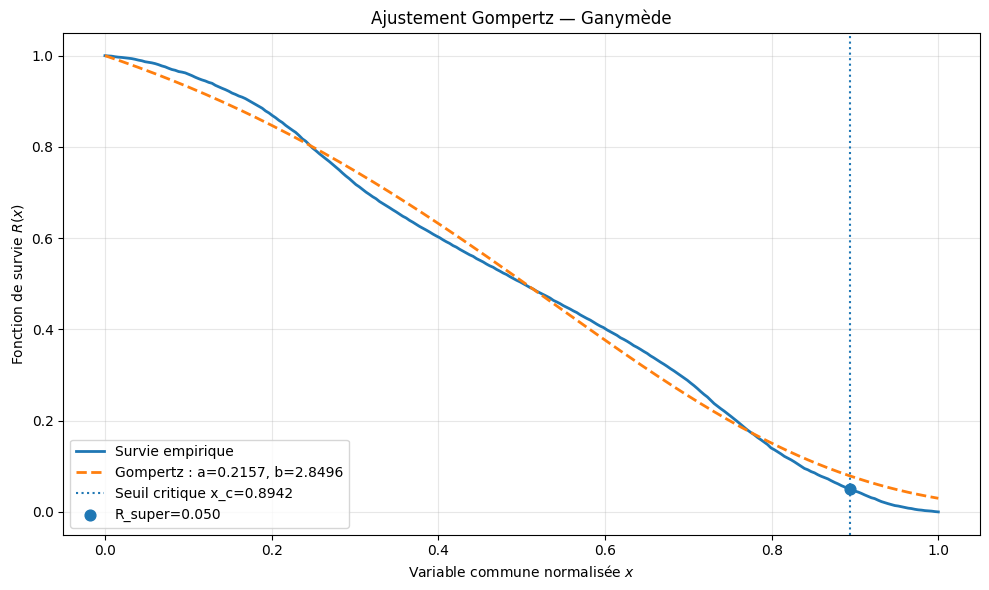


a Gompertz                 : 0.215685325622
b Gompertz                 : 2.849599343750
R²                         : 0.993435099
RMSE                       : 0.024529309
MAE                        : 0.022382773
AIC                        : -1686.796276
BIC                        : -1679.937585
R_Gompertz(u_c)            : 0.078778085
Erreur signée au seuil     : 0.028778085
Erreur absolue au seuil    : 0.028778085

Ajustement Gompertz validé.


In [12]:
# ============================================================
# 11. Ajustement Gompertz — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

print("=" * 90)
print("AJUSTEMENT GOMPERTZ — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Modèle de Gompertz décroissant
# ------------------------------------------------------------

def modele_gompertz(x, a_G, b_G):
    argument_interne = np.clip(
        b_G * x,
        -100,
        100
    )

    exposant = -a_G * (
        np.exp(argument_interne) - 1.0
    )

    exposant = np.clip(
        exposant,
        -700,
        0
    )

    return np.exp(exposant)

# ------------------------------------------------------------
# 2. Valeurs initiales
# ------------------------------------------------------------

a_initial_G = 0.15
b_initial_G = 3.0

# ------------------------------------------------------------
# 3. Ajustement
# ------------------------------------------------------------

param_gompertz, cov_gompertz = curve_fit(
    modele_gompertz,
    x_fit_commun,
    R_fit_commun,
    p0=[a_initial_G, b_initial_G],
    bounds=(
        [1e-10, 1e-10],
        [1000.0, 1000.0]
    ),
    maxfev=100000
)

a_G = float(param_gompertz[0])
b_G = float(param_gompertz[1])

# ------------------------------------------------------------
# 4. Prédictions
# ------------------------------------------------------------

R_gompertz_fit = modele_gompertz(
    x_fit_commun,
    a_G,
    b_G
)

R_gompertz = modele_gompertz(
    x_modele,
    a_G,
    b_G
)

comparaison_modeles_ganymede[
    "R_gompertz"
] = R_gompertz

# ------------------------------------------------------------
# 5. Résidus et métriques
# ------------------------------------------------------------

residus_gompertz = (
    R_fit_commun - R_gompertz_fit
)

SSE_gompertz = float(
    np.sum(residus_gompertz**2)
)

RMSE_gompertz = float(
    np.sqrt(
        np.mean(residus_gompertz**2)
    )
)

MAE_gompertz = float(
    np.mean(
        np.abs(residus_gompertz)
    )
)

SST_gompertz = float(
    np.sum(
        (
            R_fit_commun
            - np.mean(R_fit_commun)
        )**2
    )
)

R2_gompertz = float(
    1.0 - SSE_gompertz / SST_gompertz
)

n_gompertz = len(R_fit_commun)
p_gompertz = 2

AIC_gompertz = float(
    n_gompertz
    * np.log(SSE_gompertz / n_gompertz)
    + 2 * p_gompertz
)

BIC_gompertz = float(
    n_gompertz
    * np.log(SSE_gompertz / n_gompertz)
    + p_gompertz * np.log(n_gompertz)
)

# ------------------------------------------------------------
# 6. Évaluation au seuil critique
# ------------------------------------------------------------

x_uc = float(
    (u_c - u_min_modele) / amplitude_u
)

R_gompertz_uc = float(
    modele_gompertz(
        x_uc,
        a_G,
        b_G
    )
)

Erreur_gompertz_uc = float(
    R_gompertz_uc - R_super
)

Erreur_absolue_gompertz_uc = float(
    abs(Erreur_gompertz_uc)
)

# ------------------------------------------------------------
# 7. Résumé
# ------------------------------------------------------------

resume_gompertz = pd.DataFrame({
    "Observable": [
        "a",
        "b",
        "R2",
        "RMSE",
        "MAE",
        "AIC",
        "BIC",
        "R(u_c)",
        "Erreur signée (u_c)",
        "Erreur absolue (u_c)"
    ],
    "Valeur": [
        a_G,
        b_G,
        R2_gompertz,
        RMSE_gompertz,
        MAE_gompertz,
        AIC_gompertz,
        BIC_gompertz,
        R_gompertz_uc,
        Erreur_gompertz_uc,
        Erreur_absolue_gompertz_uc
    ]
})

display(resume_gompertz)

# ------------------------------------------------------------
# 8. Contrôles
# ------------------------------------------------------------

controle_gompertz = pd.DataFrame({
    "Contrôle": [
        "a strictement positif",
        "b strictement positif",
        "R² fini",
        "RMSE fini",
        "Prédictions finies",
        "Prédictions comprises entre 0 et 1",
        "Courbe monotone décroissante",
        "R(0) égal à 1",
        "Valeur au seuil comprise entre 0 et 1"
    ],
    "Résultat": [
        bool(np.isfinite(a_G) and a_G > 0),
        bool(np.isfinite(b_G) and b_G > 0),
        bool(np.isfinite(R2_gompertz)),
        bool(np.isfinite(RMSE_gompertz)),
        bool(np.isfinite(R_gompertz).all()),
        bool(
            (R_gompertz >= 0).all()
            and (R_gompertz <= 1).all()
        ),
        bool(
            np.all(
                np.diff(R_gompertz) <= 1e-12
            )
        ),
        bool(
            np.isclose(
                modele_gompertz(0.0, a_G, b_G),
                1.0,
                atol=1e-12
            )
        ),
        bool(
            0.0 <= R_gompertz_uc <= 1.0
        )
    ]
})

display(controle_gompertz)

# ------------------------------------------------------------
# 9. Graphique
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    x_modele,
    R_modele,
    linewidth=2,
    label="Survie empirique"
)

plt.plot(
    x_modele,
    R_gompertz,
    "--",
    linewidth=2,
    label=(
        f"Gompertz : "
        f"a={a_G:.4f}, b={b_G:.4f}"
    )
)

plt.axvline(
    x_uc,
    linestyle=":",
    label=f"Seuil critique x_c={x_uc:.4f}"
)

plt.scatter(
    [x_uc],
    [R_super],
    s=60,
    zorder=5,
    label=f"R_super={R_super:.3f}"
)

plt.xlabel("Variable commune normalisée $x$")
plt.ylabel("Fonction de survie $R(x)$")
plt.title(
    "Ajustement Gompertz — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Résumé textuel
# ------------------------------------------------------------

print(f"\na Gompertz                 : {a_G:.12f}")
print(f"b Gompertz                 : {b_G:.12f}")
print(f"R²                         : {R2_gompertz:.9f}")
print(f"RMSE                       : {RMSE_gompertz:.9f}")
print(f"MAE                        : {MAE_gompertz:.9f}")
print(f"AIC                        : {AIC_gompertz:.6f}")
print(f"BIC                        : {BIC_gompertz:.6f}")
print(f"R_Gompertz(u_c)            : {R_gompertz_uc:.9f}")
print(f"Erreur signée au seuil     : {Erreur_gompertz_uc:.9f}")
print(f"Erreur absolue au seuil    : {Erreur_absolue_gompertz_uc:.9f}")

if controle_gompertz["Résultat"].all():
    print("\nAjustement Gompertz validé.")
else:
    print("\nAttention : au moins un contrôle Gompertz a échoué.")

COMPARAISON FINALE DES MODÈLES DE SURVIE — GANYMÈDE


,Modèle,Nombre_paramètres,R2,RMSE,MAE,AIC,BIC,R_modele_uc,Erreur_signee_uc,Erreur_absolue_uc,Rang_R2,Rang_RMSE,Rang_MAE,Rang_AIC,Rang_BIC,Rang_seuil,Score_global,Rang_global
0,Gompertz,2,0.993435,0.024529,0.022383,-1686.796276,-1679.937585,0.078778,0.028778,0.028778,1,1,1,1,1,1,6,1
1,Weibull,2,0.987379,0.034011,0.028067,-1537.764041,-1530.905349,0.110478,0.060478,0.060478,2,2,2,2,2,3,13,2
2,Logistique,2,0.985341,0.036655,0.033035,-1503.633578,-1496.774887,0.096032,0.046032,0.046032,3,3,3,3,3,2,17,3
3,Exponentielle stabilisée,2,0.936317,0.076398,0.064954,-1168.740949,-1161.882258,0.192642,0.142642,0.142642,4,4,4,4,4,4,24,4


,Modèle,Delta_AIC,Delta_BIC,Poids_Akaike,Rang_global
0,Gompertz,0.000000,0.000000,1.000000e+00,1
1,Weibull,149.032235,149.032235,4.345715e-33,2
2,Logistique,183.162698,183.162698,1.685488e-40,3
3,Exponentielle stabilisée,518.055327,518.055327,3.204167e-113,4


,Contrôle,Résultat
0,Quatre modèles présents,True
1,Toutes les métriques sont finies,True
2,Tous les modèles ont le même nombre de paramètres,True
3,Poids d'Akaike somme à 1,True
4,Un meilleur modèle global identifié,True
5,Gompertz meilleur R²,True
6,Gompertz meilleure RMSE,True
7,Gompertz meilleur AIC,True
8,Gompertz meilleur au seuil,True


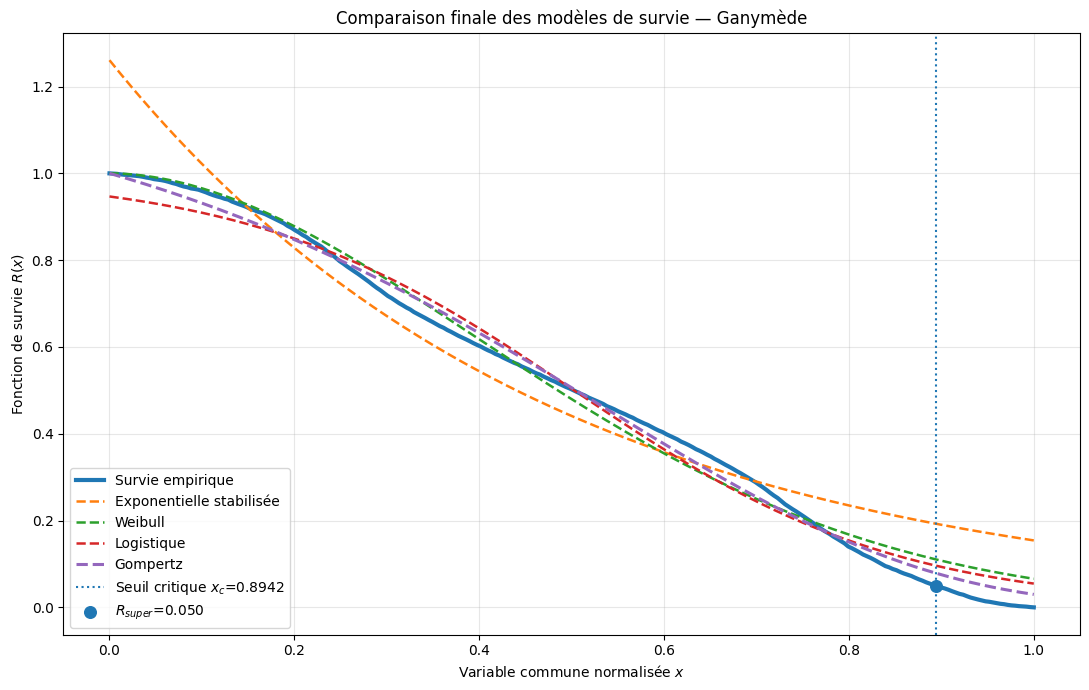


MEILLEURS MODÈLES PAR CRITÈRE
--------------------------------------------------
Meilleur R²                 : Gompertz
Plus faible RMSE            : Gompertz
Plus faible MAE             : Gompertz
Plus faible AIC             : Gompertz
Plus faible BIC             : Gompertz
Meilleur au seuil critique  : Gompertz
Meilleur classement global  : Gompertz

Comparaison finale validée.


In [13]:
# ============================================================
# 12. Comparaison finale des modèles — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("COMPARAISON FINALE DES MODÈLES DE SURVIE — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Tableau des métriques
# ------------------------------------------------------------

comparaison_finale_modeles = pd.DataFrame({
    "Modèle": [
        "Exponentielle stabilisée",
        "Weibull",
        "Logistique",
        "Gompertz"
    ],

    "Nombre_paramètres": [
        2,
        2,
        2,
        2
    ],

    "R2": [
        R2_H_centre,
        R2,
        R2_logistique,
        R2_gompertz
    ],

    "RMSE": [
        RMSE_H_centre,
        RMSE,
        RMSE_logistique,
        RMSE_gompertz
    ],

    "MAE": [
        MAE_H_centre,
        MAE,
        MAE_logistique,
        MAE_gompertz
    ],

    "AIC": [
        AIC_H_centre,
        AIC,
        AIC_logistique,
        AIC_gompertz
    ],

    "BIC": [
        BIC_H_centre,
        BIC,
        BIC_logistique,
        BIC_gompertz
    ],

    "R_modele_uc": [
        R_centre_uc,
        R_uc,
        R_logistique_uc,
        R_gompertz_uc
    ],

    "Erreur_signee_uc": [
        erreur_centre_uc,
        Erreur_uc,
        Erreur_logistique_uc,
        Erreur_gompertz_uc
    ]
})

comparaison_finale_modeles[
    "Erreur_absolue_uc"
] = comparaison_finale_modeles[
    "Erreur_signee_uc"
].abs()

# ------------------------------------------------------------
# 2. Classements individuels
# ------------------------------------------------------------

comparaison_finale_modeles["Rang_R2"] = (
    comparaison_finale_modeles["R2"]
    .rank(ascending=False, method="min")
    .astype(int)
)

comparaison_finale_modeles["Rang_RMSE"] = (
    comparaison_finale_modeles["RMSE"]
    .rank(ascending=True, method="min")
    .astype(int)
)

comparaison_finale_modeles["Rang_MAE"] = (
    comparaison_finale_modeles["MAE"]
    .rank(ascending=True, method="min")
    .astype(int)
)

comparaison_finale_modeles["Rang_AIC"] = (
    comparaison_finale_modeles["AIC"]
    .rank(ascending=True, method="min")
    .astype(int)
)

comparaison_finale_modeles["Rang_BIC"] = (
    comparaison_finale_modeles["BIC"]
    .rank(ascending=True, method="min")
    .astype(int)
)

comparaison_finale_modeles["Rang_seuil"] = (
    comparaison_finale_modeles["Erreur_absolue_uc"]
    .rank(ascending=True, method="min")
    .astype(int)
)

# ------------------------------------------------------------
# 3. Score global
# ------------------------------------------------------------

colonnes_rangs = [
    "Rang_R2",
    "Rang_RMSE",
    "Rang_MAE",
    "Rang_AIC",
    "Rang_BIC",
    "Rang_seuil"
]

comparaison_finale_modeles["Score_global"] = (
    comparaison_finale_modeles[
        colonnes_rangs
    ].sum(axis=1)
)

comparaison_finale_modeles["Rang_global"] = (
    comparaison_finale_modeles[
        "Score_global"
    ]
    .rank(ascending=True, method="min")
    .astype(int)
)

# ------------------------------------------------------------
# 4. Tri final
# ------------------------------------------------------------

comparaison_finale_modeles = (
    comparaison_finale_modeles
    .sort_values(
        by=[
            "Rang_global",
            "AIC"
        ]
    )
    .reset_index(drop=True)
)

display(comparaison_finale_modeles)

# ------------------------------------------------------------
# 5. Identification automatique des gagnants
# ------------------------------------------------------------

meilleur_R2 = comparaison_finale_modeles.loc[
    comparaison_finale_modeles["R2"].idxmax(),
    "Modèle"
]

meilleur_RMSE = comparaison_finale_modeles.loc[
    comparaison_finale_modeles["RMSE"].idxmin(),
    "Modèle"
]

meilleur_MAE = comparaison_finale_modeles.loc[
    comparaison_finale_modeles["MAE"].idxmin(),
    "Modèle"
]

meilleur_AIC = comparaison_finale_modeles.loc[
    comparaison_finale_modeles["AIC"].idxmin(),
    "Modèle"
]

meilleur_BIC = comparaison_finale_modeles.loc[
    comparaison_finale_modeles["BIC"].idxmin(),
    "Modèle"
]

meilleur_seuil = comparaison_finale_modeles.loc[
    comparaison_finale_modeles[
        "Erreur_absolue_uc"
    ].idxmin(),
    "Modèle"
]

meilleur_global = comparaison_finale_modeles.loc[
    comparaison_finale_modeles[
        "Score_global"
    ].idxmin(),
    "Modèle"
]

# ------------------------------------------------------------
# 6. Delta AIC et delta BIC
# ------------------------------------------------------------

AIC_min = float(
    comparaison_finale_modeles["AIC"].min()
)

BIC_min = float(
    comparaison_finale_modeles["BIC"].min()
)

comparaison_finale_modeles["Delta_AIC"] = (
    comparaison_finale_modeles["AIC"]
    - AIC_min
)

comparaison_finale_modeles["Delta_BIC"] = (
    comparaison_finale_modeles["BIC"]
    - BIC_min
)

# Poids d'Akaike
poids_AIC_non_normalises = np.exp(
    -0.5
    * comparaison_finale_modeles["Delta_AIC"]
)

comparaison_finale_modeles["Poids_Akaike"] = (
    poids_AIC_non_normalises
    / poids_AIC_non_normalises.sum()
)

display(
    comparaison_finale_modeles[
        [
            "Modèle",
            "Delta_AIC",
            "Delta_BIC",
            "Poids_Akaike",
            "Rang_global"
        ]
    ]
)

# ------------------------------------------------------------
# 7. Contrôles
# ------------------------------------------------------------

controle_comparaison_finale = pd.DataFrame({
    "Contrôle": [
        "Quatre modèles présents",
        "Toutes les métriques sont finies",
        "Tous les modèles ont le même nombre de paramètres",
        "Poids d'Akaike somme à 1",
        "Un meilleur modèle global identifié",
        "Gompertz meilleur R²",
        "Gompertz meilleure RMSE",
        "Gompertz meilleur AIC",
        "Gompertz meilleur au seuil"
    ],

    "Résultat": [
        len(comparaison_finale_modeles) == 4,

        bool(
            np.isfinite(
                comparaison_finale_modeles[
                    [
                        "R2",
                        "RMSE",
                        "MAE",
                        "AIC",
                        "BIC",
                        "Erreur_absolue_uc"
                    ]
                ].to_numpy()
            ).all()
        ),

        comparaison_finale_modeles[
            "Nombre_paramètres"
        ].nunique() == 1,

        bool(
            np.isclose(
                comparaison_finale_modeles[
                    "Poids_Akaike"
                ].sum(),
                1.0
            )
        ),

        isinstance(meilleur_global, str),

        meilleur_R2 == "Gompertz",

        meilleur_RMSE == "Gompertz",

        meilleur_AIC == "Gompertz",

        meilleur_seuil == "Gompertz"
    ]
})

display(controle_comparaison_finale)

# ------------------------------------------------------------
# 8. Graphique commun
# ------------------------------------------------------------

plt.figure(figsize=(11, 7))

plt.plot(
    x_modele,
    R_modele,
    linewidth=3,
    label="Survie empirique"
)

plt.plot(
    x_modele,
    R_exp_centre_complet,
    "--",
    linewidth=1.8,
    label="Exponentielle stabilisée"
)

plt.plot(
    x_modele,
    R_weibull,
    "--",
    linewidth=1.8,
    label="Weibull"
)

plt.plot(
    x_modele,
    R_logistique,
    "--",
    linewidth=1.8,
    label="Logistique"
)

plt.plot(
    x_modele,
    R_gompertz,
    "--",
    linewidth=2.2,
    label="Gompertz"
)

plt.axvline(
    x_uc,
    linestyle=":",
    label=f"Seuil critique $x_c$={x_uc:.4f}"
)

plt.scatter(
    [x_uc],
    [R_super],
    s=70,
    zorder=5,
    label=f"$R_{{super}}$={R_super:.3f}"
)

plt.xlabel("Variable commune normalisée $x$")
plt.ylabel("Fonction de survie $R(x)$")
plt.title(
    "Comparaison finale des modèles de survie — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Résumé textuel
# ------------------------------------------------------------

print("\nMEILLEURS MODÈLES PAR CRITÈRE")
print("-" * 50)
print(f"Meilleur R²                 : {meilleur_R2}")
print(f"Plus faible RMSE            : {meilleur_RMSE}")
print(f"Plus faible MAE             : {meilleur_MAE}")
print(f"Plus faible AIC             : {meilleur_AIC}")
print(f"Plus faible BIC             : {meilleur_BIC}")
print(f"Meilleur au seuil critique  : {meilleur_seuil}")
print(f"Meilleur classement global  : {meilleur_global}")

if controle_comparaison_finale["Résultat"].all():
    print(
        "\nComparaison finale validée."
    )
else:
    print(
        "\nAttention : au moins un contrôle final a échoué."
    )

OBSERVABLES ANGULAIRES — GANYMÈDE


,Observable,Valeur
0,Nombre d'angles,8759.000000
1,theta_min,2.090579
2,theta_mean,2.096567
3,theta_median,2.096544
4,theta_std,0.003054
5,theta_max,2.102931
6,R_170,0.000000
7,R_175,0.000000
8,R_180,0.000000


,Contrôle,Résultat
0,Nombre d'angles = transitions - 1,True
1,Angles sans NaN,True
2,Angles finis,True
3,Angles supérieurs ou égaux à 0°,True
4,Angles inférieurs ou égaux à 180°,True
5,theta_max supérieur ou égal à theta_mean,True
6,R_170 compris entre 0 et 1,True
7,R_175 compris entre 0 et 1,True
8,R_175 inférieur ou égal à R_170,True


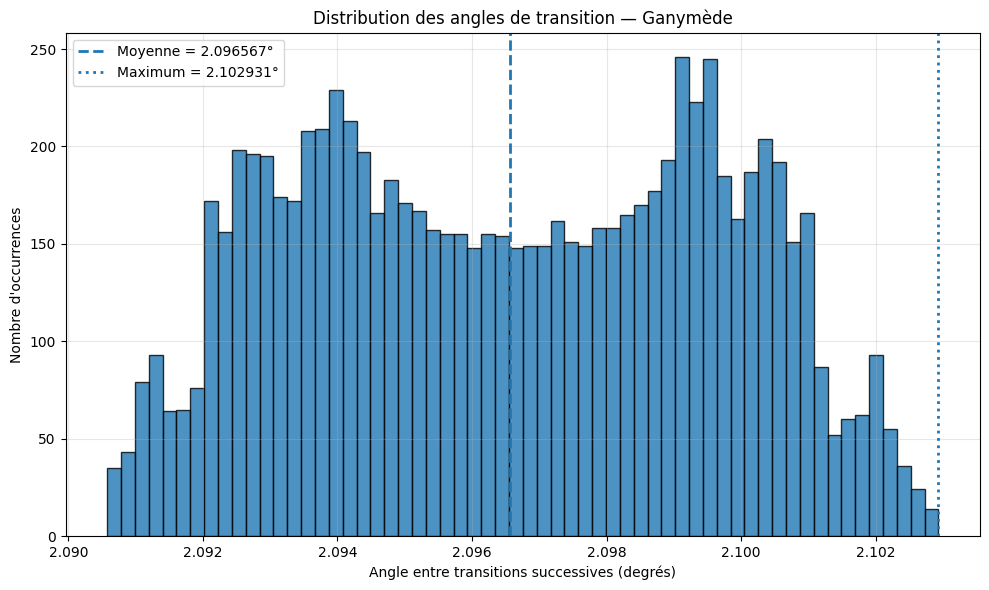

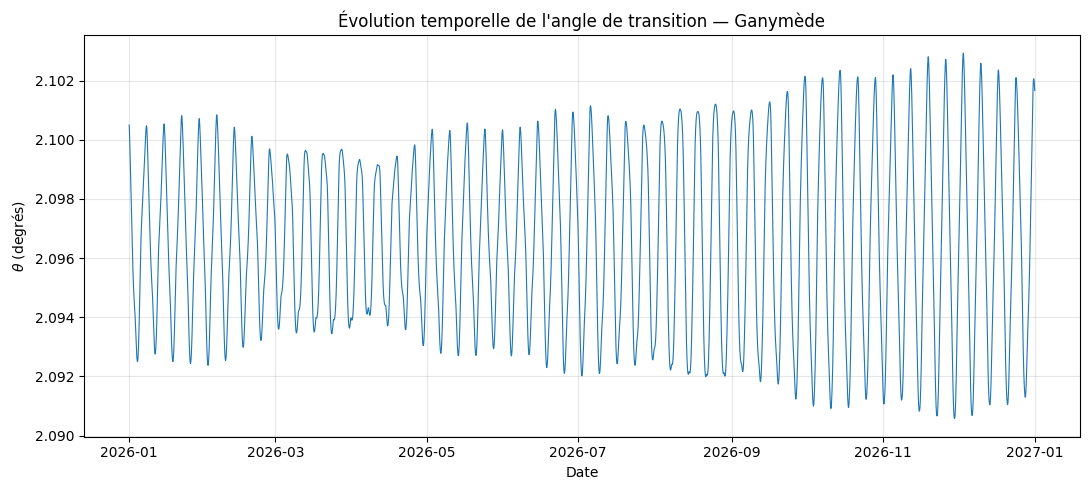


Nombre d'angles             : 8759
Angle minimum               : 2.090578799142°
Angle moyen                 : 2.096566704010°
Angle médian                : 2.096543769645°
Écart-type angulaire        : 0.003053587118°
Angle maximum               : 2.102930918421°
Fraction theta >= 170°      : 0.000000000000
Fraction theta >= 175°      : 0.000000000000
Observable R_180            : 0.000000000000

Observables angulaires validées.


In [14]:
# ============================================================
# 13. Observables angulaires — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("OBSERVABLES ANGULAIRES — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Vérification des colonnes nécessaires
# ------------------------------------------------------------

colonnes_requises = ["dX", "dY", "dZ", "D_T"]

colonnes_absentes = [
    colonne
    for colonne in colonnes_requises
    if colonne not in ganymede.columns
]

if colonnes_absentes:
    raise KeyError(
        "Colonnes manquantes : "
        + ", ".join(colonnes_absentes)
    )

# ------------------------------------------------------------
# 2. Vecteurs de transition
# ------------------------------------------------------------

vecteurs_transition = ganymede[
    ["dX", "dY", "dZ"]
].to_numpy(dtype=float)

normes_transition = np.linalg.norm(
    vecteurs_transition,
    axis=1
)

# Deux vecteurs successifs
vecteurs_precedents = vecteurs_transition[:-1]
vecteurs_suivants = vecteurs_transition[1:]

normes_precedentes = normes_transition[:-1]
normes_suivantes = normes_transition[1:]

# ------------------------------------------------------------
# 3. Produits scalaires et cosinus
# ------------------------------------------------------------

produits_scalaires = np.einsum(
    "ij,ij->i",
    vecteurs_precedents,
    vecteurs_suivants
)

denominateurs = (
    normes_precedentes
    * normes_suivantes
)

if np.any(denominateurs <= 0):
    raise ValueError(
        "Au moins une norme de transition est nulle."
    )

cos_theta = (
    produits_scalaires
    / denominateurs
)

# Protection contre les erreurs d'arrondi
cos_theta = np.clip(
    cos_theta,
    -1.0,
    1.0
)

# ------------------------------------------------------------
# 4. Angles en degrés
# ------------------------------------------------------------

theta_rad = np.arccos(cos_theta)
theta_deg = np.degrees(theta_rad)

# ------------------------------------------------------------
# 5. DataFrame angulaire
# ------------------------------------------------------------

angles_ganymede = pd.DataFrame({
    "Datetime": ganymede["Datetime"].iloc[1:].to_numpy(),
    "cos_theta": cos_theta,
    "theta_deg": theta_deg
})

# Ajout dans le DataFrame principal :
# la première transition ne possède pas d'angle précédent
ganymede["theta_deg"] = np.nan
ganymede.loc[
    ganymede.index[1:],
    "theta_deg"
] = theta_deg

# ------------------------------------------------------------
# 6. Observables angulaires
# ------------------------------------------------------------

theta_mean = float(
    np.mean(theta_deg)
)

theta_median = float(
    np.median(theta_deg)
)

theta_std = float(
    np.std(theta_deg, ddof=1)
)

theta_min = float(
    np.min(theta_deg)
)

theta_max = float(
    np.max(theta_deg)
)

# Fractions de retournements presque antiparallèles
R_170 = float(
    np.mean(theta_deg >= 170.0)
)

R_175 = float(
    np.mean(theta_deg >= 175.0)
)

# Convention GVH retenue pour R_180 :
# fraction des angles supérieurs ou égaux à 170°
R_180 = R_170

# ------------------------------------------------------------
# 7. Tableau récapitulatif
# ------------------------------------------------------------

resume_angles_ganymede = pd.DataFrame({
    "Observable": [
        "Nombre d'angles",
        "theta_min",
        "theta_mean",
        "theta_median",
        "theta_std",
        "theta_max",
        "R_170",
        "R_175",
        "R_180"
    ],
    "Valeur": [
        len(theta_deg),
        theta_min,
        theta_mean,
        theta_median,
        theta_std,
        theta_max,
        R_170,
        R_175,
        R_180
    ]
})

display(resume_angles_ganymede)

# ------------------------------------------------------------
# 8. Contrôles
# ------------------------------------------------------------

controle_angles_ganymede = pd.DataFrame({
    "Contrôle": [
        "Nombre d'angles = transitions - 1",
        "Angles sans NaN",
        "Angles finis",
        "Angles supérieurs ou égaux à 0°",
        "Angles inférieurs ou égaux à 180°",
        "theta_max supérieur ou égal à theta_mean",
        "R_170 compris entre 0 et 1",
        "R_175 compris entre 0 et 1",
        "R_175 inférieur ou égal à R_170"
    ],
    "Résultat": [
        len(theta_deg) == len(ganymede) - 1,
        bool(not np.isnan(theta_deg).any()),
        bool(np.isfinite(theta_deg).all()),
        bool((theta_deg >= 0.0).all()),
        bool((theta_deg <= 180.0 + 1e-10).all()),
        theta_max >= theta_mean,
        0.0 <= R_170 <= 1.0,
        0.0 <= R_175 <= 1.0,
        R_175 <= R_170
    ]
})

display(controle_angles_ganymede)

# ------------------------------------------------------------
# 9. Histogramme
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    theta_deg,
    bins=60,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    theta_mean,
    linestyle="--",
    linewidth=2,
    label=f"Moyenne = {theta_mean:.6f}°"
)

plt.axvline(
    theta_max,
    linestyle=":",
    linewidth=2,
    label=f"Maximum = {theta_max:.6f}°"
)

plt.xlabel("Angle entre transitions successives (degrés)")
plt.ylabel("Nombre d'occurrences")
plt.title(
    "Distribution des angles de transition — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Série temporelle
# ------------------------------------------------------------

plt.figure(figsize=(11, 5))

plt.plot(
    angles_ganymede["Datetime"],
    angles_ganymede["theta_deg"],
    linewidth=0.8
)

plt.xlabel("Date")
plt.ylabel(r"$\theta$ (degrés)")
plt.title(
    "Évolution temporelle de l'angle de transition — Ganymède"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Résumé textuel
# ------------------------------------------------------------

print(f"\nNombre d'angles             : {len(theta_deg)}")
print(f"Angle minimum               : {theta_min:.12f}°")
print(f"Angle moyen                 : {theta_mean:.12f}°")
print(f"Angle médian                : {theta_median:.12f}°")
print(f"Écart-type angulaire        : {theta_std:.12f}°")
print(f"Angle maximum               : {theta_max:.12f}°")
print(f"Fraction theta >= 170°      : {R_170:.12f}")
print(f"Fraction theta >= 175°      : {R_175:.12f}")
print(f"Observable R_180            : {R_180:.12f}")

if controle_angles_ganymede["Résultat"].all():
    print("\nObservables angulaires validées.")
else:
    print("\nAttention : au moins un contrôle angulaire a échoué.")

PÉRIODE GÉOMÉTRIQUE ORBITALE — GANYMÈDE


,Observable,Valeur
0,omega_rad_h,0.036592
1,omega_deg_h,2.096568
2,Sens orbital,croissant
3,Période géométrique (h),171.709163
4,Période géométrique (j),7.154548
5,Période locale médiane (h),171.582708
6,Écart-type période locale (h),0.51023
7,Nombre de cycles couverts,51.010533
8,R2_phase,1.0
9,RMSE_phase_deg,0.167866


,Contrôle,Résultat
0,Temps strictement croissant,True
1,Longitude sans NaN,True
2,Phase déroulée sans NaN,True
3,Vitesse angulaire non nulle,True
4,Période positive et finie,True
5,R² fini,True
6,"R² supérieur à 0,99",True
7,Plus d'un cycle couvert,True
8,Périodes locales finies,True


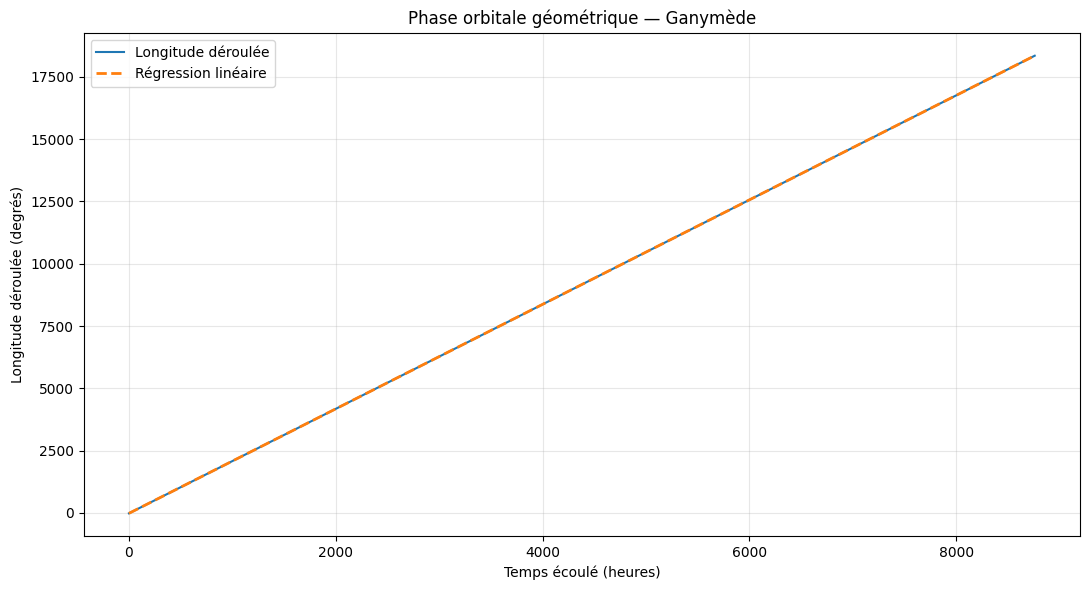

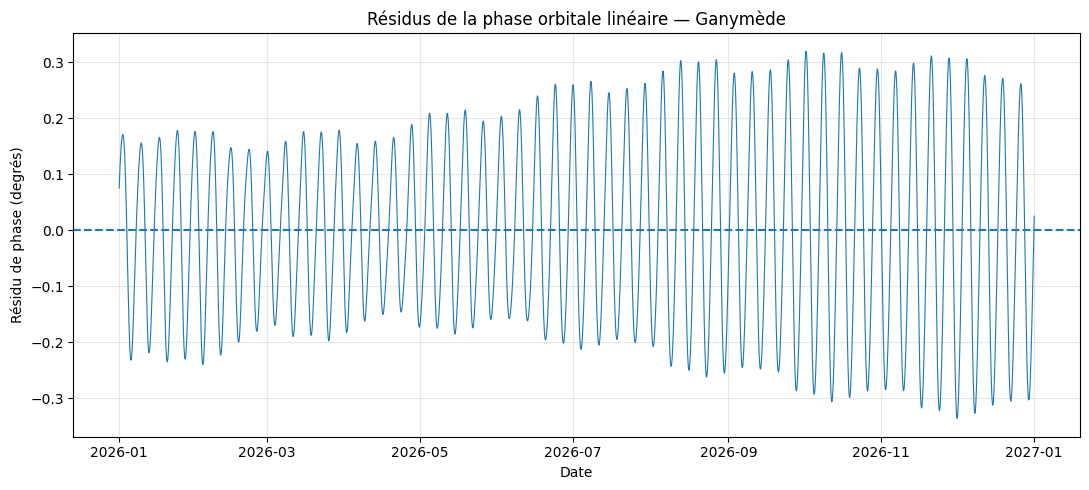


Vitesse angulaire             : 2.096568369955°/h
Sens de variation de phase    : croissant
Période géométrique           : 171.709163011 h
Période géométrique           : 7.154548458787 j
Période locale médiane        : 171.582708216 h
Nombre de cycles              : 51.010533
R² de la phase                : 0.999999998998
RMSE de phase                 : 0.167865929°
Résidu maximal                : 0.336244323°

Période géométrique validée.


In [15]:
# ============================================================
# 14. Période géométrique orbitale — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("PÉRIODE GÉOMÉTRIQUE ORBITALE — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Vérification des colonnes
# ------------------------------------------------------------

colonnes_requises = ["Datetime", "X", "Y", "Z"]

colonnes_absentes = [
    colonne
    for colonne in colonnes_requises
    if colonne not in ganymede.columns
]

if colonnes_absentes:
    raise KeyError(
        "Colonnes manquantes : "
        + ", ".join(colonnes_absentes)
    )

# ------------------------------------------------------------
# 2. Temps écoulé depuis la première observation
# ------------------------------------------------------------

temps_heures = (
    ganymede["Datetime"]
    - ganymede["Datetime"].iloc[0]
).dt.total_seconds().to_numpy(dtype=float) / 3600.0

# ------------------------------------------------------------
# 3. Longitude jovicentrique
# ------------------------------------------------------------

X_orbite = ganymede["X"].to_numpy(dtype=float)
Y_orbite = ganymede["Y"].to_numpy(dtype=float)

longitude_rad = np.arctan2(
    Y_orbite,
    X_orbite
)

longitude_deg = np.degrees(
    longitude_rad
)

# Déroulement de la phase
longitude_deroulee_rad = np.unwrap(
    longitude_rad
)

longitude_deroulee_deg = np.degrees(
    longitude_deroulee_rad
)

# ------------------------------------------------------------
# 4. Régression linéaire de la phase
# ------------------------------------------------------------

coefficients_phase = np.polyfit(
    temps_heures,
    longitude_deroulee_rad,
    1
)

omega_rad_h = float(coefficients_phase[0])
phase_initiale_rad = float(coefficients_phase[1])

phase_modele_rad = (
    omega_rad_h * temps_heures
    + phase_initiale_rad
)

phase_modele_deg = np.degrees(
    phase_modele_rad
)

# ------------------------------------------------------------
# 5. Période géométrique
# ------------------------------------------------------------

if np.isclose(omega_rad_h, 0.0):
    raise ValueError(
        "La vitesse angulaire ajustée est nulle."
    )

periode_geometrique_h = float(
    2.0 * np.pi / abs(omega_rad_h)
)

periode_geometrique_j = float(
    periode_geometrique_h / 24.0
)

omega_deg_h = float(
    np.degrees(omega_rad_h)
)

sens_orbital = (
    "croissant"
    if omega_rad_h > 0
    else "décroissant"
)

# ------------------------------------------------------------
# 6. Qualité de l'ajustement
# ------------------------------------------------------------

residus_phase_rad = (
    longitude_deroulee_rad
    - phase_modele_rad
)

residus_phase_deg = np.degrees(
    residus_phase_rad
)

SSE_phase = float(
    np.sum(residus_phase_rad**2)
)

SST_phase = float(
    np.sum(
        (
            longitude_deroulee_rad
            - np.mean(longitude_deroulee_rad)
        )**2
    )
)

R2_phase = float(
    1.0 - SSE_phase / SST_phase
)

RMSE_phase_deg = float(
    np.sqrt(
        np.mean(residus_phase_deg**2)
    )
)

MAE_phase_deg = float(
    np.mean(
        np.abs(residus_phase_deg)
    )
)

residu_phase_max_deg = float(
    np.max(
        np.abs(residus_phase_deg)
    )
)

# ------------------------------------------------------------
# 7. Vitesse angulaire locale
# ------------------------------------------------------------

delta_phase_rad = np.diff(
    longitude_deroulee_rad
)

delta_t_h = np.diff(
    temps_heures
)

omega_locale_rad_h = (
    delta_phase_rad / delta_t_h
)

periode_locale_h = (
    2.0 * np.pi
    / np.abs(omega_locale_rad_h)
)

periode_locale_mediane_h = float(
    np.median(periode_locale_h)
)

periode_locale_std_h = float(
    np.std(periode_locale_h, ddof=1)
)

# ------------------------------------------------------------
# 8. Nombre de cycles couverts
# ------------------------------------------------------------

variation_phase_rad = float(
    longitude_deroulee_rad[-1]
    - longitude_deroulee_rad[0]
)

nombre_cycles = float(
    abs(variation_phase_rad)
    / (2.0 * np.pi)
)

# ------------------------------------------------------------
# 9. DataFrame géométrique
# ------------------------------------------------------------

geometrie_ganymede = pd.DataFrame({
    "Datetime": ganymede["Datetime"].to_numpy(),
    "Temps_heures": temps_heures,
    "Longitude_deg": longitude_deg,
    "Longitude_deroulee_deg": longitude_deroulee_deg,
    "Longitude_modele_deg": phase_modele_deg,
    "Residu_phase_deg": residus_phase_deg
})

# Ajout au DataFrame principal
ganymede["Longitude_deg"] = longitude_deg
ganymede["Longitude_deroulee_deg"] = longitude_deroulee_deg
ganymede["Residu_phase_deg"] = residus_phase_deg

# ------------------------------------------------------------
# 10. Résumé
# ------------------------------------------------------------

resume_periode_geometrique = pd.DataFrame({
    "Observable": [
        "omega_rad_h",
        "omega_deg_h",
        "Sens orbital",
        "Période géométrique (h)",
        "Période géométrique (j)",
        "Période locale médiane (h)",
        "Écart-type période locale (h)",
        "Nombre de cycles couverts",
        "R2_phase",
        "RMSE_phase_deg",
        "MAE_phase_deg",
        "Résidu maximal absolu (deg)"
    ],
    "Valeur": [
        omega_rad_h,
        omega_deg_h,
        sens_orbital,
        periode_geometrique_h,
        periode_geometrique_j,
        periode_locale_mediane_h,
        periode_locale_std_h,
        nombre_cycles,
        R2_phase,
        RMSE_phase_deg,
        MAE_phase_deg,
        residu_phase_max_deg
    ]
})

display(resume_periode_geometrique)

# ------------------------------------------------------------
# 11. Contrôles
# ------------------------------------------------------------

controle_periode_geometrique = pd.DataFrame({
    "Contrôle": [
        "Temps strictement croissant",
        "Longitude sans NaN",
        "Phase déroulée sans NaN",
        "Vitesse angulaire non nulle",
        "Période positive et finie",
        "R² fini",
        "R² supérieur à 0,99",
        "Plus d'un cycle couvert",
        "Périodes locales finies"
    ],
    "Résultat": [
        bool(np.all(np.diff(temps_heures) > 0)),
        bool(np.isfinite(longitude_rad).all()),
        bool(np.isfinite(longitude_deroulee_rad).all()),
        bool(not np.isclose(omega_rad_h, 0.0)),
        bool(
            np.isfinite(periode_geometrique_h)
            and periode_geometrique_h > 0
        ),
        bool(np.isfinite(R2_phase)),
        bool(R2_phase > 0.99),
        bool(nombre_cycles > 1),
        bool(np.isfinite(periode_locale_h).all())
    ]
})

display(controle_periode_geometrique)

# ------------------------------------------------------------
# 12. Graphique de phase
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.plot(
    temps_heures,
    longitude_deroulee_deg,
    linewidth=1.5,
    label="Longitude déroulée"
)

plt.plot(
    temps_heures,
    phase_modele_deg,
    "--",
    linewidth=2,
    label="Régression linéaire"
)

plt.xlabel("Temps écoulé (heures)")
plt.ylabel("Longitude déroulée (degrés)")
plt.title(
    "Phase orbitale géométrique — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Graphique des résidus
# ------------------------------------------------------------

plt.figure(figsize=(11, 5))

plt.plot(
    ganymede["Datetime"],
    residus_phase_deg,
    linewidth=0.8
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Résidu de phase (degrés)")
plt.title(
    "Résidus de la phase orbitale linéaire — Ganymède"
)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 14. Résumé textuel
# ------------------------------------------------------------

print(f"\nVitesse angulaire             : {omega_deg_h:.12f}°/h")
print(f"Sens de variation de phase    : {sens_orbital}")
print(f"Période géométrique           : {periode_geometrique_h:.9f} h")
print(f"Période géométrique           : {periode_geometrique_j:.12f} j")
print(f"Période locale médiane        : {periode_locale_mediane_h:.9f} h")
print(f"Nombre de cycles              : {nombre_cycles:.6f}")
print(f"R² de la phase                : {R2_phase:.12f}")
print(f"RMSE de phase                 : {RMSE_phase_deg:.9f}°")
print(f"Résidu maximal                : {residu_phase_max_deg:.9f}°")

if controle_periode_geometrique["Résultat"].all():
    print("\nPériode géométrique validée.")
else:
    print("\nAttention : au moins un contrôle géométrique a échoué.")

ANALYSE FFT DE LA PÉRIODE ORBITALE — GANYMÈDE


,Observable,Valeur
0,Nombre d'échantillons,8760
1,Pas temporel (h),1.0
2,Durée couverte (h),8759.0
3,Résolution fréquentielle (h^-1),0.000114
4,Fréquence brute (h^-1),0.005822
5,Période FFT brute (h),171.764706
6,Interpolation effectuée,True
7,Fréquence interpolée (h^-1),0.005824
8,Période FFT interpolée (h),171.704445
9,Période FFT interpolée (j),7.154352


,Contrôle,Résultat
0,Pas temporel constant,True
1,FFT X finie,True
2,FFT Y finie,True
3,Puissance finie,True
4,Fréquence du pic positive,True
5,Période FFT positive et finie,True
6,Période FFT comprise entre 100 h et 300 h,True
7,Interpolation valide,True
8,Écart relatif à la géométrie inférieur à 1 %,True


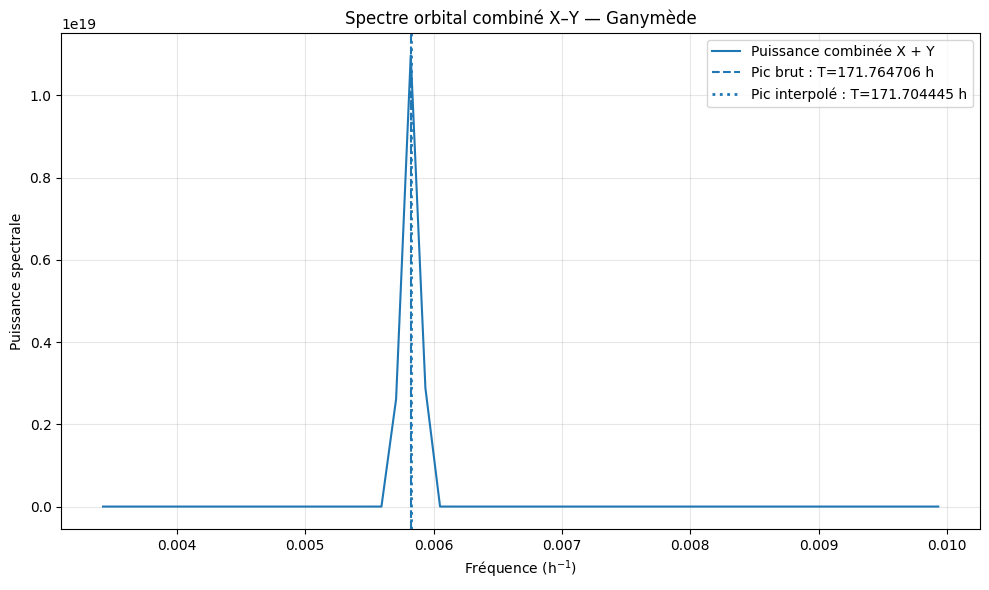

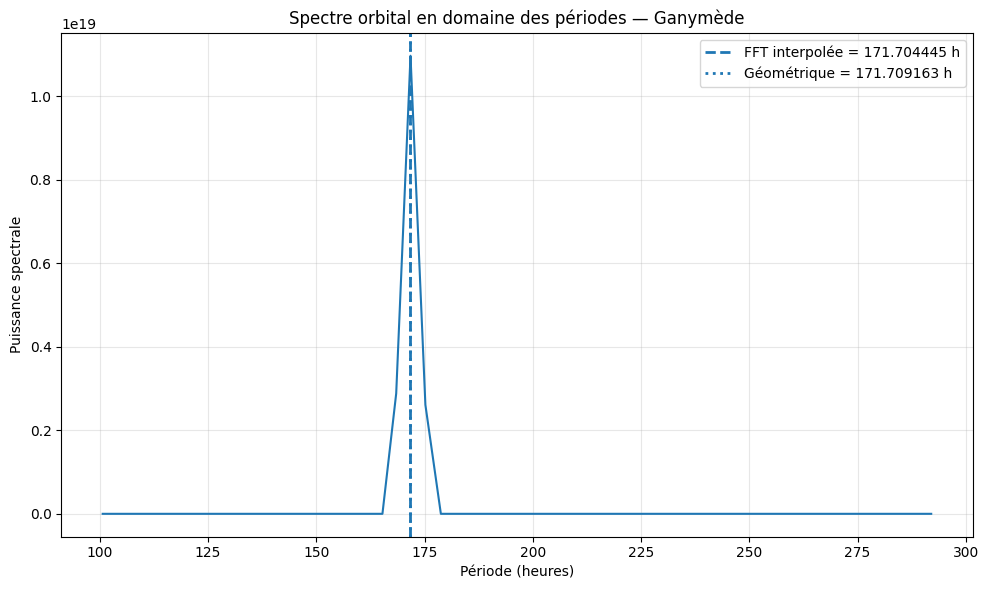


Pic fréquentiel brut          : 0.005821917808 h⁻¹
Période FFT brute             : 171.764705882 h
Pic fréquentiel interpolé     : 0.005823961049 h⁻¹
Période FFT interpolée        : 171.704445068 h
Période FFT interpolée        : 7.154351877837 j
Période géométrique           : 171.709163011 h
Écart FFT - géométrique       : -0.004717943 h
Écart FFT - géométrique       : -16.984594 s
Erreur relative               : 0.002747636 %

Analyse FFT validée.


In [16]:
# ============================================================
# 15. Analyse FFT de la période orbitale — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("ANALYSE FFT DE LA PÉRIODE ORBITALE — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Vérification des données
# ------------------------------------------------------------

colonnes_requises = ["Datetime", "X", "Y"]

colonnes_absentes = [
    colonne
    for colonne in colonnes_requises
    if colonne not in ganymede.columns
]

if colonnes_absentes:
    raise KeyError(
        "Colonnes manquantes : "
        + ", ".join(colonnes_absentes)
    )

temps_fft_h = (
    ganymede["Datetime"]
    - ganymede["Datetime"].iloc[0]
).dt.total_seconds().to_numpy(dtype=float) / 3600.0

delta_t_fft_h = np.diff(temps_fft_h)

pas_fft_h = float(np.mean(delta_t_fft_h))

if not np.allclose(
    delta_t_fft_h,
    pas_fft_h,
    rtol=0,
    atol=1e-9
):
    raise ValueError(
        "La FFT exige un échantillonnage temporel régulier."
    )

# ------------------------------------------------------------
# 2. Séries centrées
# ------------------------------------------------------------

X_fft = ganymede["X"].to_numpy(dtype=float)
Y_fft = ganymede["Y"].to_numpy(dtype=float)

X_centre = X_fft - np.mean(X_fft)
Y_centre = Y_fft - np.mean(Y_fft)

N_fft = len(X_centre)

# Fenêtre de Hann pour limiter les fuites spectrales
fenetre_fft = np.hanning(N_fft)

X_fenetre = X_centre * fenetre_fft
Y_fenetre = Y_centre * fenetre_fft

# ------------------------------------------------------------
# 3. Transformées de Fourier
# ------------------------------------------------------------

fft_X = np.fft.rfft(X_fenetre)
fft_Y = np.fft.rfft(Y_fenetre)

frequences_h_inv = np.fft.rfftfreq(
    N_fft,
    d=pas_fft_h
)

puissance_X = np.abs(fft_X) ** 2
puissance_Y = np.abs(fft_Y) ** 2

puissance_combinee = (
    puissance_X + puissance_Y
)

# Suppression de la fréquence nulle
masque_frequences_positives = (
    frequences_h_inv > 0
)

frequences_pos = frequences_h_inv[
    masque_frequences_positives
]

puissance_pos = puissance_combinee[
    masque_frequences_positives
]

# ------------------------------------------------------------
# 4. Recherche du pic orbital
# ------------------------------------------------------------

# Domaine raisonnable autour de la période géométrique :
# périodes comprises entre 100 h et 300 h
frequence_min = 1.0 / 300.0
frequence_max = 1.0 / 100.0

masque_orbital = (
    (frequences_pos >= frequence_min)
    & (frequences_pos <= frequence_max)
)

frequences_orbitales = frequences_pos[
    masque_orbital
]

puissance_orbitale = puissance_pos[
    masque_orbital
]

if len(frequences_orbitales) < 3:
    raise ValueError(
        "Domaine fréquentiel orbital insuffisant."
    )

indice_pic_local = int(
    np.argmax(puissance_orbitale)
)

frequence_pic_brute = float(
    frequences_orbitales[indice_pic_local]
)

periode_fft_brute_h = float(
    1.0 / frequence_pic_brute
)

# ------------------------------------------------------------
# 5. Interpolation parabolique du pic
# ------------------------------------------------------------

frequence_fft_interp = frequence_pic_brute
interpolation_effectuee = False

if (
    0 < indice_pic_local
    < len(puissance_orbitale) - 1
):
    y_m1 = np.log(
        max(
            puissance_orbitale[indice_pic_local - 1],
            np.finfo(float).tiny
        )
    )

    y_0 = np.log(
        max(
            puissance_orbitale[indice_pic_local],
            np.finfo(float).tiny
        )
    )

    y_p1 = np.log(
        max(
            puissance_orbitale[indice_pic_local + 1],
            np.finfo(float).tiny
        )
    )

    denominateur_parabole = (
        y_m1 - 2.0 * y_0 + y_p1
    )

    if not np.isclose(
        denominateur_parabole,
        0.0
    ):
        decalage_bin = float(
            0.5
            * (y_m1 - y_p1)
            / denominateur_parabole
        )

        resolution_f = float(
            frequences_orbitales[1]
            - frequences_orbitales[0]
        )

        frequence_fft_interp = float(
            frequence_pic_brute
            + decalage_bin * resolution_f
        )

        interpolation_effectuee = True

periode_fft_h = float(
    1.0 / frequence_fft_interp
)

periode_fft_j = float(
    periode_fft_h / 24.0
)

# ------------------------------------------------------------
# 6. Comparaison avec la période géométrique
# ------------------------------------------------------------

ecart_fft_geometrique_h = float(
    periode_fft_h
    - periode_geometrique_h
)

ecart_fft_geometrique_s = float(
    ecart_fft_geometrique_h * 3600.0
)

erreur_relative_fft = float(
    abs(ecart_fft_geometrique_h)
    / periode_geometrique_h
)

erreur_relative_fft_pct = float(
    100.0 * erreur_relative_fft
)

# ------------------------------------------------------------
# 7. Résolution spectrale
# ------------------------------------------------------------

duree_totale_fft_h = float(
    temps_fft_h[-1]
    - temps_fft_h[0]
)

resolution_f_h_inv = float(
    1.0 / (N_fft * pas_fft_h)
)

resolution_periode_approx_h = float(
    resolution_f_h_inv
    / frequence_fft_interp**2
)

# ------------------------------------------------------------
# 8. Tableau récapitulatif
# ------------------------------------------------------------

resume_fft_ganymede = pd.DataFrame({
    "Observable": [
        "Nombre d'échantillons",
        "Pas temporel (h)",
        "Durée couverte (h)",
        "Résolution fréquentielle (h^-1)",
        "Fréquence brute (h^-1)",
        "Période FFT brute (h)",
        "Interpolation effectuée",
        "Fréquence interpolée (h^-1)",
        "Période FFT interpolée (h)",
        "Période FFT interpolée (j)",
        "Résolution période approx. (h)",
        "Période géométrique (h)",
        "Écart FFT - géométrique (h)",
        "Écart FFT - géométrique (s)",
        "Erreur relative FFT (%)"
    ],
    "Valeur": [
        N_fft,
        pas_fft_h,
        duree_totale_fft_h,
        resolution_f_h_inv,
        frequence_pic_brute,
        periode_fft_brute_h,
        interpolation_effectuee,
        frequence_fft_interp,
        periode_fft_h,
        periode_fft_j,
        resolution_periode_approx_h,
        periode_geometrique_h,
        ecart_fft_geometrique_h,
        ecart_fft_geometrique_s,
        erreur_relative_fft_pct
    ]
})

display(resume_fft_ganymede)

# ------------------------------------------------------------
# 9. Contrôles
# ------------------------------------------------------------

controle_fft_ganymede = pd.DataFrame({
    "Contrôle": [
        "Pas temporel constant",
        "FFT X finie",
        "FFT Y finie",
        "Puissance finie",
        "Fréquence du pic positive",
        "Période FFT positive et finie",
        "Période FFT comprise entre 100 h et 300 h",
        "Interpolation valide",
        "Écart relatif à la géométrie inférieur à 1 %"
    ],
    "Résultat": [
        bool(
            np.allclose(
                delta_t_fft_h,
                pas_fft_h,
                rtol=0,
                atol=1e-9
            )
        ),
        bool(np.isfinite(fft_X).all()),
        bool(np.isfinite(fft_Y).all()),
        bool(np.isfinite(puissance_combinee).all()),
        frequence_fft_interp > 0,
        bool(
            np.isfinite(periode_fft_h)
            and periode_fft_h > 0
        ),
        100.0 <= periode_fft_h <= 300.0,
        bool(
            np.isfinite(frequence_fft_interp)
        ),
        erreur_relative_fft < 0.01
    ]
})

display(controle_fft_ganymede)

# ------------------------------------------------------------
# 10. Spectre autour de la fréquence orbitale
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    frequences_orbitales,
    puissance_orbitale,
    linewidth=1.5,
    label="Puissance combinée X + Y"
)

plt.axvline(
    frequence_pic_brute,
    linestyle="--",
    linewidth=1.5,
    label=(
        f"Pic brut : "
        f"T={periode_fft_brute_h:.6f} h"
    )
)

plt.axvline(
    frequence_fft_interp,
    linestyle=":",
    linewidth=2,
    label=(
        f"Pic interpolé : "
        f"T={periode_fft_h:.6f} h"
    )
)

plt.xlabel("Fréquence (h$^{-1}$)")
plt.ylabel("Puissance spectrale")
plt.title(
    "Spectre orbital combiné X–Y — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 11. Spectre exprimé en périodes
# ------------------------------------------------------------

periodes_orbitales_h = (
    1.0 / frequences_orbitales
)

ordre_periodes = np.argsort(
    periodes_orbitales_h
)

plt.figure(figsize=(10, 6))

plt.plot(
    periodes_orbitales_h[ordre_periodes],
    puissance_orbitale[ordre_periodes],
    linewidth=1.5
)

plt.axvline(
    periode_fft_h,
    linestyle="--",
    linewidth=2,
    label=f"FFT interpolée = {periode_fft_h:.6f} h"
)

plt.axvline(
    periode_geometrique_h,
    linestyle=":",
    linewidth=2,
    label=(
        f"Géométrique = "
        f"{periode_geometrique_h:.6f} h"
    )
)

plt.xlabel("Période (heures)")
plt.ylabel("Puissance spectrale")
plt.title(
    "Spectre orbital en domaine des périodes — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Résumé textuel
# ------------------------------------------------------------

print(f"\nPic fréquentiel brut          : {frequence_pic_brute:.12f} h⁻¹")
print(f"Période FFT brute             : {periode_fft_brute_h:.9f} h")
print(f"Pic fréquentiel interpolé     : {frequence_fft_interp:.12f} h⁻¹")
print(f"Période FFT interpolée        : {periode_fft_h:.9f} h")
print(f"Période FFT interpolée        : {periode_fft_j:.12f} j")
print(f"Période géométrique           : {periode_geometrique_h:.9f} h")
print(f"Écart FFT - géométrique       : {ecart_fft_geometrique_h:.9f} h")
print(f"Écart FFT - géométrique       : {ecart_fft_geometrique_s:.6f} s")
print(f"Erreur relative               : {erreur_relative_fft_pct:.9f} %")

if controle_fft_ganymede["Résultat"].all():
    print("\nAnalyse FFT validée.")
else:
    print("\nAttention : au moins un contrôle FFT a échoué.")

FERMETURE ORBITALE 3D — GANYMÈDE


,Observable,Valeur
0,Nombre d'états originaux,8.761000e+03
1,Nombre de paires utilisées,8.589000e+03
2,Pas temporel original (h),1.000000e+00
3,Rayon médian de référence (km),1.070435e+06
4,Période minimale sur grille (h),1.717068e+02
5,Période de fermeture optimisée (h),1.717092e+02
6,Période de fermeture optimisée (j),7.154549e+00
7,C_best (km),3.340019e+02
8,C_best_norm,3.120243e-04
9,Angle fermeture RMS (deg),1.437790e-02


,Contrôle,Résultat
0,8761 états originaux disponibles,True
1,Temps strictement croissant,True
2,Positions finies,True
3,Optimisation réussie,True
4,Période comprise entre les bornes,True
5,Métrique de fermeture positive et finie,True
6,C_best_norm inférieur à 1 %,True
7,Angle RMS fini,True
8,Écart à la géométrie inférieur à 1 %,True
9,Écart à la FFT inférieur à 1 %,True


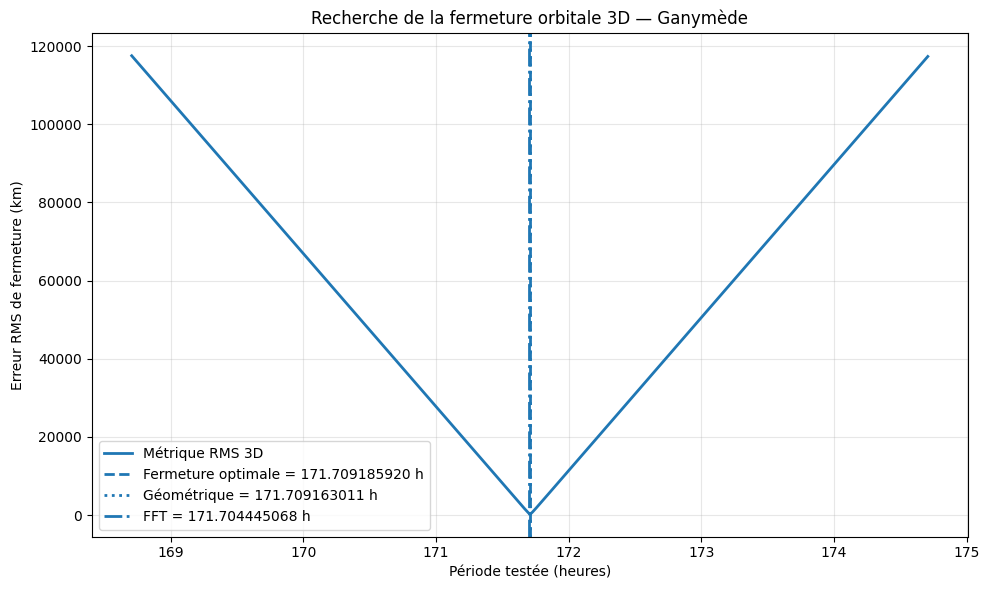

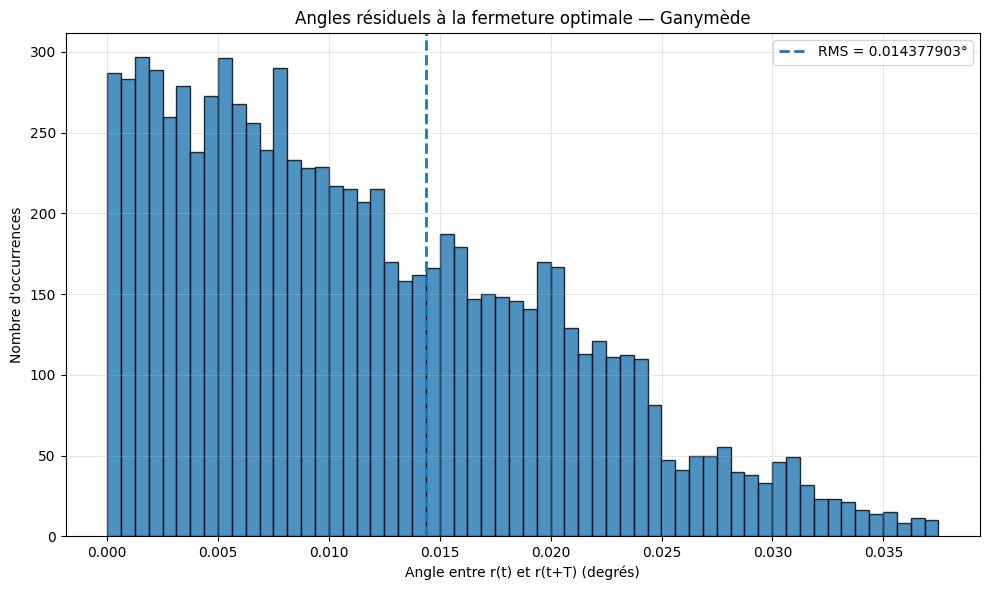


Période de fermeture          : 171.709185920406 h
Période de fermeture          : 7.154549413350 j
Métrique C_best               : 334.001885834 km
Métrique normalisée           : 3.120243054540e-04
Angle de fermeture RMS        : 0.014377902609°
Écart fermeture - géométrie   : 0.082474 s
Écart fermeture - FFT         : 17.067068 s
Erreur relative à géométrie   : 0.000013342 %

Fermeture orbitale 3D validée.


In [17]:
# ============================================================
# 16. Fermeture orbitale 3D — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize_scalar

print("=" * 90)
print("FERMETURE ORBITALE 3D — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Sélection des états orbitaux originaux
# ------------------------------------------------------------

if "ganymede_clean" in globals():
    donnees_fermeture = ganymede_clean.copy()
else:
    raise NameError(
        "Le DataFrame ganymede_clean est requis pour utiliser "
        "les 8761 états originaux."
    )

colonnes_requises = ["Datetime", "X", "Y", "Z"]

colonnes_absentes = [
    colonne
    for colonne in colonnes_requises
    if colonne not in donnees_fermeture.columns
]

if colonnes_absentes:
    raise KeyError(
        "Colonnes manquantes : "
        + ", ".join(colonnes_absentes)
    )

donnees_fermeture = (
    donnees_fermeture
    .sort_values("Datetime")
    .reset_index(drop=True)
)

# ------------------------------------------------------------
# 2. Temps et positions
# ------------------------------------------------------------

temps_closure_h = (
    donnees_fermeture["Datetime"]
    - donnees_fermeture["Datetime"].iloc[0]
).dt.total_seconds().to_numpy(dtype=float) / 3600.0

X_closure = donnees_fermeture["X"].to_numpy(dtype=float)
Y_closure = donnees_fermeture["Y"].to_numpy(dtype=float)
Z_closure = donnees_fermeture["Z"].to_numpy(dtype=float)

positions_closure = np.column_stack([
    X_closure,
    Y_closure,
    Z_closure
])

rayons_closure = np.linalg.norm(
    positions_closure,
    axis=1
)

rayon_reference = float(
    np.median(rayons_closure)
)

pas_closure_h = float(
    np.median(np.diff(temps_closure_h))
)

# ------------------------------------------------------------
# 3. Fonction de fermeture
# ------------------------------------------------------------

def metrique_fermeture_3d(T_h):
    """
    RMS de ||r(t+T)-r(t)|| sur tous les couples temporels
    disponibles, avec interpolation linéaire des coordonnées.
    """

    if not np.isfinite(T_h) or T_h <= 0:
        return np.inf

    temps_decalés = temps_closure_h + T_h

    masque_valide = (
        temps_decalés <= temps_closure_h[-1]
    )

    if masque_valide.sum() < 100:
        return np.inf

    t_cible = temps_decalés[masque_valide]

    X_interp = np.interp(
        t_cible,
        temps_closure_h,
        X_closure
    )

    Y_interp = np.interp(
        t_cible,
        temps_closure_h,
        Y_closure
    )

    Z_interp = np.interp(
        t_cible,
        temps_closure_h,
        Z_closure
    )

    positions_initiales = positions_closure[
        masque_valide
    ]

    positions_decalees = np.column_stack([
        X_interp,
        Y_interp,
        Z_interp
    ])

    ecarts = (
        positions_decalees
        - positions_initiales
    )

    distances = np.linalg.norm(
        ecarts,
        axis=1
    )

    return float(
        np.sqrt(np.mean(distances**2))
    )

# ------------------------------------------------------------
# 4. Domaine de recherche
# ------------------------------------------------------------

# Recherche autour des deux estimations déjà obtenues,
# sans imposer leur valeur exacte.
periode_centrale_h = float(
    0.5 * (
        periode_geometrique_h
        + periode_fft_h
    )
)

borne_inf_h = float(
    periode_centrale_h - 3.0
)

borne_sup_h = float(
    periode_centrale_h + 3.0
)

# Grille diagnostique
periodes_test_h = np.linspace(
    borne_inf_h,
    borne_sup_h,
    601
)

metriques_test_km = np.array([
    metrique_fermeture_3d(T_h)
    for T_h in periodes_test_h
])

indice_min_grille = int(
    np.argmin(metriques_test_km)
)

periode_grille_h = float(
    periodes_test_h[indice_min_grille]
)

# ------------------------------------------------------------
# 5. Optimisation continue
# ------------------------------------------------------------

resultat_fermeture = minimize_scalar(
    metrique_fermeture_3d,
    bounds=(borne_inf_h, borne_sup_h),
    method="bounded",
    options={
        "xatol": 1e-10,
        "maxiter": 1000
    }
)

if not resultat_fermeture.success:
    raise RuntimeError(
        "L'optimisation de la fermeture orbitale a échoué : "
        + str(resultat_fermeture.message)
    )

periode_fermeture_h = float(
    resultat_fermeture.x
)

periode_fermeture_j = float(
    periode_fermeture_h / 24.0
)

C_best_km = float(
    resultat_fermeture.fun
)

C_best_norm = float(
    C_best_km / rayon_reference
)

# ------------------------------------------------------------
# 6. Angle de fermeture
# ------------------------------------------------------------

temps_decale_best = (
    temps_closure_h
    + periode_fermeture_h
)

masque_best = (
    temps_decale_best
    <= temps_closure_h[-1]
)

t_cible_best = temps_decale_best[
    masque_best
]

positions_depart_best = positions_closure[
    masque_best
]

positions_retour_best = np.column_stack([
    np.interp(
        t_cible_best,
        temps_closure_h,
        X_closure
    ),
    np.interp(
        t_cible_best,
        temps_closure_h,
        Y_closure
    ),
    np.interp(
        t_cible_best,
        temps_closure_h,
        Z_closure
    )
])

produits_best = np.einsum(
    "ij,ij->i",
    positions_depart_best,
    positions_retour_best
)

normes_best = (
    np.linalg.norm(
        positions_depart_best,
        axis=1
    )
    *
    np.linalg.norm(
        positions_retour_best,
        axis=1
    )
)

cos_fermeture = np.clip(
    produits_best / normes_best,
    -1.0,
    1.0
)

angles_fermeture_deg = np.degrees(
    np.arccos(cos_fermeture)
)

angle_fermeture_rms_deg = float(
    np.sqrt(
        np.mean(
            angles_fermeture_deg**2
        )
    )
)

angle_fermeture_median_deg = float(
    np.median(
        angles_fermeture_deg
    )
)

angle_fermeture_max_deg = float(
    np.max(
        angles_fermeture_deg
    )
)

# ------------------------------------------------------------
# 7. Comparaison avec géométrie et FFT
# ------------------------------------------------------------

ecart_closure_geom_h = float(
    periode_fermeture_h
    - periode_geometrique_h
)

ecart_closure_fft_h = float(
    periode_fermeture_h
    - periode_fft_h
)

ecart_closure_geom_s = float(
    ecart_closure_geom_h * 3600.0
)

ecart_closure_fft_s = float(
    ecart_closure_fft_h * 3600.0
)

erreur_relative_closure_geom_pct = float(
    100.0
    * abs(ecart_closure_geom_h)
    / periode_geometrique_h
)

# ------------------------------------------------------------
# 8. Nombre de paires utilisées
# ------------------------------------------------------------

nombre_paires_fermeture = int(
    masque_best.sum()
)

# ------------------------------------------------------------
# 9. Tableau récapitulatif
# ------------------------------------------------------------

resume_fermeture_ganymede = pd.DataFrame({
    "Observable": [
        "Nombre d'états originaux",
        "Nombre de paires utilisées",
        "Pas temporel original (h)",
        "Rayon médian de référence (km)",
        "Période minimale sur grille (h)",
        "Période de fermeture optimisée (h)",
        "Période de fermeture optimisée (j)",
        "C_best (km)",
        "C_best_norm",
        "Angle fermeture RMS (deg)",
        "Angle fermeture médian (deg)",
        "Angle fermeture maximal (deg)",
        "Période géométrique (h)",
        "Période FFT (h)",
        "Écart fermeture - géométrique (h)",
        "Écart fermeture - géométrique (s)",
        "Écart fermeture - FFT (h)",
        "Écart fermeture - FFT (s)",
        "Erreur relative fermeture/géométrie (%)"
    ],
    "Valeur": [
        len(donnees_fermeture),
        nombre_paires_fermeture,
        pas_closure_h,
        rayon_reference,
        periode_grille_h,
        periode_fermeture_h,
        periode_fermeture_j,
        C_best_km,
        C_best_norm,
        angle_fermeture_rms_deg,
        angle_fermeture_median_deg,
        angle_fermeture_max_deg,
        periode_geometrique_h,
        periode_fft_h,
        ecart_closure_geom_h,
        ecart_closure_geom_s,
        ecart_closure_fft_h,
        ecart_closure_fft_s,
        erreur_relative_closure_geom_pct
    ]
})

display(resume_fermeture_ganymede)

# ------------------------------------------------------------
# 10. Contrôles
# ------------------------------------------------------------

controle_fermeture_ganymede = pd.DataFrame({
    "Contrôle": [
        "8761 états originaux disponibles",
        "Temps strictement croissant",
        "Positions finies",
        "Optimisation réussie",
        "Période comprise entre les bornes",
        "Métrique de fermeture positive et finie",
        "C_best_norm inférieur à 1 %",
        "Angle RMS fini",
        "Écart à la géométrie inférieur à 1 %",
        "Écart à la FFT inférieur à 1 %"
    ],
    "Résultat": [
        len(donnees_fermeture) == 8761,
        bool(
            np.all(
                np.diff(temps_closure_h) > 0
            )
        ),
        bool(
            np.isfinite(
                positions_closure
            ).all()
        ),
        bool(resultat_fermeture.success),
        borne_inf_h <= periode_fermeture_h <= borne_sup_h,
        bool(
            np.isfinite(C_best_km)
            and C_best_km >= 0
        ),
        C_best_norm < 0.01,
        bool(
            np.isfinite(
                angle_fermeture_rms_deg
            )
        ),
        (
            abs(ecart_closure_geom_h)
            / periode_geometrique_h
        ) < 0.01,
        (
            abs(ecart_closure_fft_h)
            / periode_fft_h
        ) < 0.01
    ]
})

display(controle_fermeture_ganymede)

# ------------------------------------------------------------
# 11. Graphique de la métrique de fermeture
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.plot(
    periodes_test_h,
    metriques_test_km,
    linewidth=2,
    label="Métrique RMS 3D"
)

plt.axvline(
    periode_fermeture_h,
    linestyle="--",
    linewidth=2,
    label=(
        f"Fermeture optimale = "
        f"{periode_fermeture_h:.9f} h"
    )
)

plt.axvline(
    periode_geometrique_h,
    linestyle=":",
    linewidth=2,
    label=(
        f"Géométrique = "
        f"{periode_geometrique_h:.9f} h"
    )
)

plt.axvline(
    periode_fft_h,
    linestyle="-.",
    linewidth=2,
    label=(
        f"FFT = "
        f"{periode_fft_h:.9f} h"
    )
)

plt.xlabel("Période testée (heures)")
plt.ylabel("Erreur RMS de fermeture (km)")
plt.title(
    "Recherche de la fermeture orbitale 3D — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 12. Distribution des angles de fermeture
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.hist(
    angles_fermeture_deg,
    bins=60,
    edgecolor="black",
    alpha=0.8
)

plt.axvline(
    angle_fermeture_rms_deg,
    linestyle="--",
    linewidth=2,
    label=(
        f"RMS = "
        f"{angle_fermeture_rms_deg:.9f}°"
    )
)

plt.xlabel("Angle entre r(t) et r(t+T) (degrés)")
plt.ylabel("Nombre d'occurrences")
plt.title(
    "Angles résiduels à la fermeture optimale — Ganymède"
)
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 13. Résumé textuel
# ------------------------------------------------------------

print(f"\nPériode de fermeture          : {periode_fermeture_h:.12f} h")
print(f"Période de fermeture          : {periode_fermeture_j:.12f} j")
print(f"Métrique C_best               : {C_best_km:.9f} km")
print(f"Métrique normalisée           : {C_best_norm:.12e}")
print(f"Angle de fermeture RMS        : {angle_fermeture_rms_deg:.12f}°")
print(f"Écart fermeture - géométrie   : {ecart_closure_geom_s:.6f} s")
print(f"Écart fermeture - FFT         : {ecart_closure_fft_s:.6f} s")
print(
    f"Erreur relative à géométrie   : "
    f"{erreur_relative_closure_geom_pct:.9f} %"
)

if controle_fermeture_ganymede["Résultat"].all():
    print("\nFermeture orbitale 3D validée.")
else:
    print("\nAttention : au moins un contrôle de fermeture a échoué.")

CONCORDANCE DES ESTIMATIONS DE PÉRIODE — GANYMÈDE


,Méthode,Période_h,Période_j,Écart_à_la_moyenne_h,Écart_à_la_moyenne_s,Erreur_relative_à_la_moyenne_pct
0,Phase géométrique,171.709163,7.154548,0.001565,5.634040,0.000911
1,FFT interpolée,171.704445,7.154352,-0.003153,-11.350554,0.001836
2,Fermeture orbitale 3D,171.709186,7.154549,0.001588,5.716514,0.000925


,Comparaison,Écart_absolu_s
0,Géométrique – FFT,16.984594
1,Géométrique – Fermeture,0.082474
2,FFT – Fermeture,17.067068


,Observable,Valeur
0,Période moyenne (h),171.707598
1,Période moyenne (j),7.154483
2,Période médiane (h),171.709163
3,Écart-type interméthodes (h),0.002731
4,Écart-type interméthodes (s),9.829955
5,Étendue totale (h),0.004741
6,Étendue totale (s),17.067068
7,Dispersion relative (%),0.001590


,Contrôle,Résultat
0,Trois méthodes présentes,True
1,Toutes les périodes sont finies,True
2,Toutes les périodes sont positives,True
3,Étendue totale inférieure à 60 s,True
4,"Dispersion relative inférieure à 0,01 %",True
5,Géométrie et fermeture séparées de moins de 1 s,True
6,FFT et géométrie séparées de moins de 60 s,True


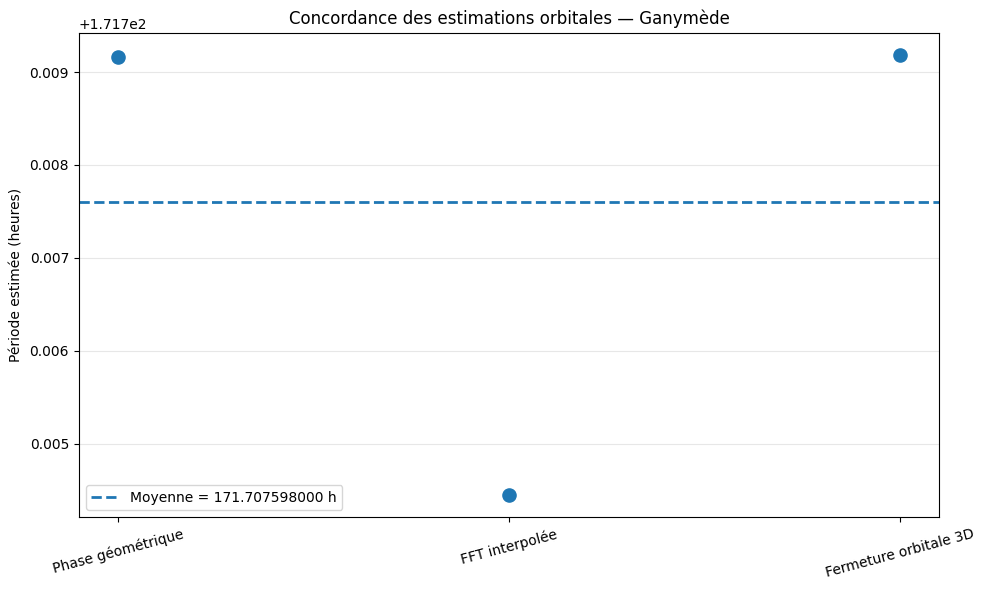


Période géométrique          : 171.709163010892 h
Période FFT interpolée       : 171.704445068094 h
Période de fermeture         : 171.709185920406 h
Période moyenne              : 171.707597999797 h
Période moyenne              : 7.154483249992 j
Écart-type interméthodes     : 9.829955 s
Étendue totale               : 17.067068 s
Dispersion relative          : 0.001590228 %

Concordance des trois estimations validée.


In [18]:
# ============================================================
# 17. Concordance des estimations de période — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("CONCORDANCE DES ESTIMATIONS DE PÉRIODE — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Périodes obtenues
# ------------------------------------------------------------

periodes_h = np.array([
    periode_geometrique_h,
    periode_fft_h,
    periode_fermeture_h
], dtype=float)

methodes = [
    "Phase géométrique",
    "FFT interpolée",
    "Fermeture orbitale 3D"
]

# ------------------------------------------------------------
# 2. Statistiques de concordance
# ------------------------------------------------------------

periode_moyenne_h = float(np.mean(periodes_h))
periode_mediane_h = float(np.median(periodes_h))
periode_std_h = float(np.std(periodes_h, ddof=1))

periode_min_h = float(np.min(periodes_h))
periode_max_h = float(np.max(periodes_h))
etendue_h = float(periode_max_h - periode_min_h)
etendue_s = float(etendue_h * 3600.0)

dispersion_relative = float(
    periode_std_h / periode_moyenne_h
)

dispersion_relative_pct = float(
    100.0 * dispersion_relative
)

# ------------------------------------------------------------
# 3. Écarts par rapport à la moyenne
# ------------------------------------------------------------

ecarts_moyenne_h = periodes_h - periode_moyenne_h
ecarts_moyenne_s = ecarts_moyenne_h * 3600.0

erreurs_relatives_moyenne_pct = (
    100.0
    * np.abs(ecarts_moyenne_h)
    / periode_moyenne_h
)

# ------------------------------------------------------------
# 4. Tableau principal
# ------------------------------------------------------------

concordance_periodes_ganymede = pd.DataFrame({
    "Méthode": methodes,
    "Période_h": periodes_h,
    "Période_j": periodes_h / 24.0,
    "Écart_à_la_moyenne_h": ecarts_moyenne_h,
    "Écart_à_la_moyenne_s": ecarts_moyenne_s,
    "Erreur_relative_à_la_moyenne_pct":
        erreurs_relatives_moyenne_pct
})

display(concordance_periodes_ganymede)

# ------------------------------------------------------------
# 5. Écarts deux à deux
# ------------------------------------------------------------

ecart_geom_fft_s = float(
    abs(periode_geometrique_h - periode_fft_h) * 3600.0
)

ecart_geom_fermeture_s = float(
    abs(periode_geometrique_h - periode_fermeture_h) * 3600.0
)

ecart_fft_fermeture_s = float(
    abs(periode_fft_h - periode_fermeture_h) * 3600.0
)

ecarts_deux_a_deux = pd.DataFrame({
    "Comparaison": [
        "Géométrique – FFT",
        "Géométrique – Fermeture",
        "FFT – Fermeture"
    ],
    "Écart_absolu_s": [
        ecart_geom_fft_s,
        ecart_geom_fermeture_s,
        ecart_fft_fermeture_s
    ]
})

display(ecarts_deux_a_deux)

# ------------------------------------------------------------
# 6. Résumé global
# ------------------------------------------------------------

resume_concordance_ganymede = pd.DataFrame({
    "Observable": [
        "Période moyenne (h)",
        "Période moyenne (j)",
        "Période médiane (h)",
        "Écart-type interméthodes (h)",
        "Écart-type interméthodes (s)",
        "Étendue totale (h)",
        "Étendue totale (s)",
        "Dispersion relative (%)"
    ],
    "Valeur": [
        periode_moyenne_h,
        periode_moyenne_h / 24.0,
        periode_mediane_h,
        periode_std_h,
        periode_std_h * 3600.0,
        etendue_h,
        etendue_s,
        dispersion_relative_pct
    ]
})

display(resume_concordance_ganymede)

# ------------------------------------------------------------
# 7. Contrôles
# ------------------------------------------------------------

controle_concordance_ganymede = pd.DataFrame({
    "Contrôle": [
        "Trois méthodes présentes",
        "Toutes les périodes sont finies",
        "Toutes les périodes sont positives",
        "Étendue totale inférieure à 60 s",
        "Dispersion relative inférieure à 0,01 %",
        "Géométrie et fermeture séparées de moins de 1 s",
        "FFT et géométrie séparées de moins de 60 s"
    ],
    "Résultat": [
        len(periodes_h) == 3,
        bool(np.isfinite(periodes_h).all()),
        bool((periodes_h > 0).all()),
        etendue_s < 60.0,
        dispersion_relative_pct < 0.01,
        ecart_geom_fermeture_s < 1.0,
        ecart_geom_fft_s < 60.0
    ]
})

display(controle_concordance_ganymede)

# ------------------------------------------------------------
# 8. Graphique
# ------------------------------------------------------------

plt.figure(figsize=(10, 6))

plt.scatter(
    methodes,
    periodes_h,
    s=90,
    zorder=5
)

plt.axhline(
    periode_moyenne_h,
    linestyle="--",
    linewidth=2,
    label=f"Moyenne = {periode_moyenne_h:.9f} h"
)

plt.ylabel("Période estimée (heures)")
plt.title(
    "Concordance des estimations orbitales — Ganymède"
)
plt.grid(axis="y", alpha=0.3)
plt.xticks(rotation=15)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Résumé textuel
# ------------------------------------------------------------

print(f"\nPériode géométrique          : {periode_geometrique_h:.12f} h")
print(f"Période FFT interpolée       : {periode_fft_h:.12f} h")
print(f"Période de fermeture         : {periode_fermeture_h:.12f} h")
print(f"Période moyenne              : {periode_moyenne_h:.12f} h")
print(f"Période moyenne              : {periode_moyenne_h / 24.0:.12f} j")
print(f"Écart-type interméthodes     : {periode_std_h * 3600.0:.6f} s")
print(f"Étendue totale               : {etendue_s:.6f} s")
print(f"Dispersion relative          : {dispersion_relative_pct:.9f} %")

if controle_concordance_ganymede["Résultat"].all():
    print("\nConcordance des trois estimations validée.")
else:
    print("\nAttention : au moins un contrôle de concordance a échoué.")

VALIDATION EXTERNE DE LA PÉRIODE — GANYMÈDE


,Méthode,Période_estimée_h,Période_estimée_j,Période_référence_h,Période_référence_j,Écart_signé_h,Écart_signé_s,Écart_absolu_s,Erreur_relative_pct
0,Phase géométrique,171.709163,7.154548,171.734112,7.155588,-0.024949,-89.816361,89.816361,0.014528
1,FFT interpolée,171.704445,7.154352,171.734112,7.155588,-0.029667,-106.800955,106.800955,0.017275
2,Fermeture orbitale 3D,171.709186,7.154549,171.734112,7.155588,-0.024926,-89.733887,89.733887,0.014514
3,Moyenne des trois méthodes,171.707598,7.154483,171.734112,7.155588,-0.026514,-95.450401,95.450401,0.015439
4,Médiane des trois méthodes,171.709163,7.154548,171.734112,7.155588,-0.024949,-89.816361,89.816361,0.014528


,Observable,Valeur
0,Source externe,JPL Solar System Dynamics — Planetary Satellit...
1,Nature de la référence,Période orbitale moyenne générale ; non spécif...
2,Période externe (j),7.155588
3,Période externe (h),171.734112
4,Meilleure méthode interne,Fermeture orbitale 3D
5,Meilleure période interne (h),171.709186
6,Écart signé minimal (s),-89.733887
7,Écart absolu minimal (s),89.733887
8,Erreur relative minimale (%),0.014514
9,Écart moyenne interne - référence (s),-95.450401


,Contrôle,Résultat
0,Référence externe positive et finie,True
1,Cinq estimations comparées,True
2,Toutes les estimations sont finies,True
3,Toutes les erreurs relatives sont finies,True
4,"Erreur géométrique inférieure à 0,1 %",True
5,"Erreur FFT inférieure à 0,1 %",True
6,"Erreur fermeture inférieure à 0,1 %",True
7,"Erreur moyenne inférieure à 0,1 %",True
8,Écart moyen absolu inférieur à 180 s,True


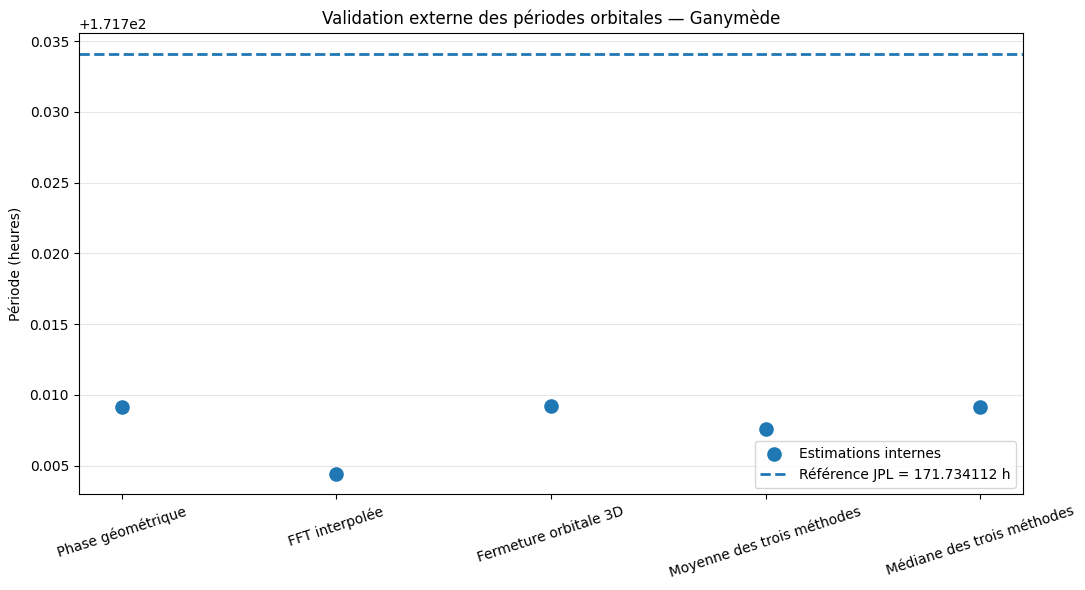

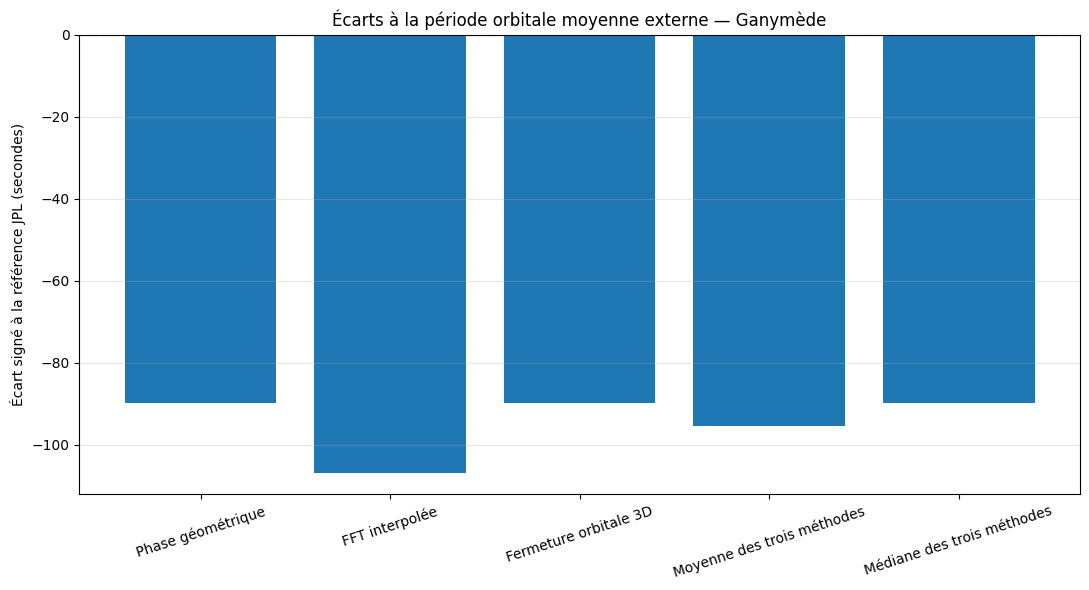


Période externe JPL          : 7.155588000 j
Période externe JPL          : 171.734112000 h
Période géométrique          : 171.709163010892 h
Écart géométrique            : -89.816361 s
Période FFT                  : 171.704445068094 h
Écart FFT                    : -106.800955 s
Période fermeture            : 171.709185920406 h
Écart fermeture              : -89.733887 s
Période moyenne interne      : 171.707597999797 h
Écart moyenne - référence    : -95.450401 s
Erreur relative moyenne      : 0.015438983 %
Meilleure concordance externe: Fermeture orbitale 3D

Validation externe réussie.


In [19]:
# ============================================================
# 18. Validation externe de la période — Ganymède
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("=" * 90)
print("VALIDATION EXTERNE DE LA PÉRIODE — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Valeur externe de référence
# ------------------------------------------------------------
# Source :
# JPL Solar System Dynamics
# Planetary Satellite Mean Elements
#
# Ganymède : période moyenne = 7.155588 jours
#
# Attention :
# il s'agit d'un élément orbital moyen général.
# Les estimations du notebook proviennent des éphémérides
# Horizons spécifiques à l'année 2026.

periode_reference_j = 7.155588
periode_reference_h = periode_reference_j * 24.0

source_reference = (
    "JPL Solar System Dynamics — "
    "Planetary Satellite Mean Elements"
)

nature_reference = (
    "Période orbitale moyenne générale ; "
    "non spécifique à l'époque 2026"
)

# ------------------------------------------------------------
# 2. Méthodes internes
# ------------------------------------------------------------

methodes_validation = [
    "Phase géométrique",
    "FFT interpolée",
    "Fermeture orbitale 3D",
    "Moyenne des trois méthodes",
    "Médiane des trois méthodes"
]

periodes_validation_h = np.array([
    periode_geometrique_h,
    periode_fft_h,
    periode_fermeture_h,
    periode_moyenne_h,
    periode_mediane_h
], dtype=float)

# ------------------------------------------------------------
# 3. Écarts à la référence
# ------------------------------------------------------------

ecarts_reference_h = (
    periodes_validation_h
    - periode_reference_h
)

ecarts_reference_s = (
    ecarts_reference_h * 3600.0
)

ecarts_absolus_s = np.abs(
    ecarts_reference_s
)

erreurs_relatives_reference_pct = (
    100.0
    * np.abs(ecarts_reference_h)
    / periode_reference_h
)

# ------------------------------------------------------------
# 4. Tableau détaillé
# ------------------------------------------------------------

validation_externe_ganymede = pd.DataFrame({
    "Méthode": methodes_validation,
    "Période_estimée_h": periodes_validation_h,
    "Période_estimée_j": periodes_validation_h / 24.0,
    "Période_référence_h": periode_reference_h,
    "Période_référence_j": periode_reference_j,
    "Écart_signé_h": ecarts_reference_h,
    "Écart_signé_s": ecarts_reference_s,
    "Écart_absolu_s": ecarts_absolus_s,
    "Erreur_relative_pct": erreurs_relatives_reference_pct
})

display(validation_externe_ganymede)

# ------------------------------------------------------------
# 5. Meilleure concordance externe
# ------------------------------------------------------------

indice_meilleure_externe = int(
    np.argmin(ecarts_absolus_s)
)

meilleure_methode_externe = methodes_validation[
    indice_meilleure_externe
]

meilleure_periode_externe_h = float(
    periodes_validation_h[indice_meilleure_externe]
)

meilleur_ecart_externe_s = float(
    ecarts_reference_s[indice_meilleure_externe]
)

meilleure_erreur_relative_pct = float(
    erreurs_relatives_reference_pct[
        indice_meilleure_externe
    ]
)

# ------------------------------------------------------------
# 6. Résumé
# ------------------------------------------------------------

resume_validation_externe = pd.DataFrame({
    "Observable": [
        "Source externe",
        "Nature de la référence",
        "Période externe (j)",
        "Période externe (h)",
        "Meilleure méthode interne",
        "Meilleure période interne (h)",
        "Écart signé minimal (s)",
        "Écart absolu minimal (s)",
        "Erreur relative minimale (%)",
        "Écart moyenne interne - référence (s)",
        "Erreur relative moyenne interne (%)"
    ],
    "Valeur": [
        source_reference,
        nature_reference,
        periode_reference_j,
        periode_reference_h,
        meilleure_methode_externe,
        meilleure_periode_externe_h,
        meilleur_ecart_externe_s,
        abs(meilleur_ecart_externe_s),
        meilleure_erreur_relative_pct,
        float(
            (
                periode_moyenne_h
                - periode_reference_h
            ) * 3600.0
        ),
        float(
            100.0
            * abs(
                periode_moyenne_h
                - periode_reference_h
            )
            / periode_reference_h
        )
    ]
})

display(resume_validation_externe)

# ------------------------------------------------------------
# 7. Contrôles
# ------------------------------------------------------------

controle_validation_externe = pd.DataFrame({
    "Contrôle": [
        "Référence externe positive et finie",
        "Cinq estimations comparées",
        "Toutes les estimations sont finies",
        "Toutes les erreurs relatives sont finies",
        "Erreur géométrique inférieure à 0,1 %",
        "Erreur FFT inférieure à 0,1 %",
        "Erreur fermeture inférieure à 0,1 %",
        "Erreur moyenne inférieure à 0,1 %",
        "Écart moyen absolu inférieur à 180 s"
    ],
    "Résultat": [
        bool(
            np.isfinite(periode_reference_h)
            and periode_reference_h > 0
        ),
        len(periodes_validation_h) == 5,
        bool(np.isfinite(periodes_validation_h).all()),
        bool(
            np.isfinite(
                erreurs_relatives_reference_pct
            ).all()
        ),
        erreurs_relatives_reference_pct[0] < 0.1,
        erreurs_relatives_reference_pct[1] < 0.1,
        erreurs_relatives_reference_pct[2] < 0.1,
        erreurs_relatives_reference_pct[3] < 0.1,
        abs(
            (
                periode_moyenne_h
                - periode_reference_h
            ) * 3600.0
        ) < 180.0
    ]
})

display(controle_validation_externe)

# ------------------------------------------------------------
# 8. Graphique des périodes
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.scatter(
    methodes_validation,
    periodes_validation_h,
    s=90,
    label="Estimations internes",
    zorder=5
)

plt.axhline(
    periode_reference_h,
    linestyle="--",
    linewidth=2,
    label=(
        f"Référence JPL = "
        f"{periode_reference_h:.6f} h"
    )
)

plt.ylabel("Période (heures)")
plt.title(
    "Validation externe des périodes orbitales — Ganymède"
)
plt.xticks(rotation=18)
plt.grid(axis="y", alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 9. Graphique des écarts en secondes
# ------------------------------------------------------------

plt.figure(figsize=(11, 6))

plt.bar(
    methodes_validation,
    ecarts_reference_s
)

plt.axhline(
    0.0,
    linestyle="--",
    linewidth=1.5
)

plt.ylabel("Écart signé à la référence JPL (secondes)")
plt.title(
    "Écarts à la période orbitale moyenne externe — Ganymède"
)
plt.xticks(rotation=18)
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 10. Résumé textuel
# ------------------------------------------------------------

print(f"\nPériode externe JPL          : {periode_reference_j:.9f} j")
print(f"Période externe JPL          : {periode_reference_h:.9f} h")

print(
    f"Période géométrique          : "
    f"{periode_geometrique_h:.12f} h"
)
print(
    f"Écart géométrique            : "
    f"{ecarts_reference_s[0]:.6f} s"
)

print(
    f"Période FFT                  : "
    f"{periode_fft_h:.12f} h"
)
print(
    f"Écart FFT                    : "
    f"{ecarts_reference_s[1]:.6f} s"
)

print(
    f"Période fermeture            : "
    f"{periode_fermeture_h:.12f} h"
)
print(
    f"Écart fermeture              : "
    f"{ecarts_reference_s[2]:.6f} s"
)

print(
    f"Période moyenne interne      : "
    f"{periode_moyenne_h:.12f} h"
)
print(
    f"Écart moyenne - référence    : "
    f"{ecarts_reference_s[3]:.6f} s"
)

print(
    f"Erreur relative moyenne      : "
    f"{erreurs_relatives_reference_pct[3]:.9f} %"
)

print(
    f"Meilleure concordance externe: "
    f"{meilleure_methode_externe}"
)

if controle_validation_externe["Résultat"].all():
    print("\nValidation externe réussie.")
else:
    print(
        "\nAttention : au moins un contrôle externe "
        "a échoué."
    )

In [20]:
# ============================================================
# 19. Exports CSV consolidés — Ganymède
# ============================================================

import os
import numpy as np
import pandas as pd

print("=" * 90)
print("EXPORTS CSV CONSOLIDÉS — GANYMÈDE")
print("=" * 90)

# ------------------------------------------------------------
# 1. Dossier de sortie
# ------------------------------------------------------------

dossier_export = "exports_ganymede"
os.makedirs(dossier_export, exist_ok=True)

# ------------------------------------------------------------
# 2. Observables GVH finales
# ------------------------------------------------------------

observables_finales_ganymede = pd.DataFrame({
    "Observable": [
        "Nombre_etats_originaux",
        "Nombre_transitions",
        "D_T_mean_km",
        "S_T_km",
        "S_T_norm",
        "D_T_min_km",
        "D_T_median_km",
        "D_T_max_km",
        "D_c_km",
        "u_c",
        "N_super",
        "R_super",
        "theta_mean_deg",
        "theta_median_deg",
        "theta_std_deg",
        "theta_max_deg",
        "R_170",
        "R_175",
        "R_180",
        "Meilleur_modele_survie",
        "Gompertz_a",
        "Gompertz_b",
        "Gompertz_R2",
        "Gompertz_RMSE",
        "Gompertz_MAE",
        "Gompertz_AIC",
        "Gompertz_BIC",
        "Gompertz_R_uc",
        "Gompertz_erreur_uc",
        "Periode_geometrique_h",
        "Periode_FFT_h",
        "Periode_fermeture_h",
        "Periode_moyenne_interne_h",
        "Periode_mediane_interne_h",
        "Dispersion_inter_methodes_s",
        "Etendue_inter_methodes_s",
        "Periode_reference_JPL_h",
        "Erreur_moyenne_reference_s",
        "Erreur_relative_moyenne_pct",
        "C_best_km",
        "C_best_norm",
        "Angle_fermeture_RMS_deg"
    ],
    "Valeur": [
        len(ganymede_clean),
        len(ganymede),
        D_T_mean,
        S_T,
        S_T_norm,
        D_T_min,
        D_T_median,
        D_T_max,
        D_c,
        u_c,
        N_super,
        R_super,
        theta_mean,
        theta_median,
        theta_std,
        theta_max,
        R_170,
        R_175,
        R_180,
        "Gompertz",
        a_G,
        b_G,
        R2_gompertz,
        RMSE_gompertz,
        MAE_gompertz,
        AIC_gompertz,
        BIC_gompertz,
        R_gompertz_uc,
        Erreur_gompertz_uc,
        periode_geometrique_h,
        periode_fft_h,
        periode_fermeture_h,
        periode_moyenne_h,
        periode_mediane_h,
        periode_std_h * 3600.0,
        etendue_s,
        periode_reference_h,
        (periode_moyenne_h - periode_reference_h) * 3600.0,
        100.0 * abs(periode_moyenne_h - periode_reference_h)
        / periode_reference_h,
        C_best_km,
        C_best_norm,
        angle_fermeture_rms_deg
    ]
})

# ------------------------------------------------------------
# 3. Transitions
# ------------------------------------------------------------

colonnes_transitions = [
    colonne for colonne in [
        "Datetime",
        "JDTDB",
        "X", "Y", "Z",
        "VX", "VY", "VZ",
        "dX", "dY", "dZ",
        "D_T",
        "u",
        "Supercritique",
        "theta_deg",
        "Longitude_deg",
        "Longitude_deroulee_deg",
        "Residu_phase_deg"
    ]
    if colonne in ganymede.columns
]

transitions_export = ganymede[
    colonnes_transitions
].copy()

# ------------------------------------------------------------
# 4. Courbe de survie et modèles
# ------------------------------------------------------------

survie_export = comparaison_modeles_ganymede.copy()

# Vérification et ajout des prédictions
colonnes_modeles = {
    "R_exponentielle_stabilisee": R_exp_centre_complet,
    "R_weibull": R_weibull,
    "R_logistique": R_logistique,
    "R_gompertz": R_gompertz
}

for nom_colonne, valeurs in colonnes_modeles.items():
    survie_export[nom_colonne] = valeurs

# ------------------------------------------------------------
# 5. Comparaison des modèles
# ------------------------------------------------------------

modeles_export = comparaison_finale_modeles.copy()

# ------------------------------------------------------------
# 6. Angles
# ------------------------------------------------------------

angles_export = angles_ganymede.copy()

# ------------------------------------------------------------
# 7. Géométrie orbitale
# ------------------------------------------------------------

geometrie_export = geometrie_ganymede.copy()

# ------------------------------------------------------------
# 8. Concordance des périodes
# ------------------------------------------------------------

periodes_export = concordance_periodes_ganymede.copy()

# ------------------------------------------------------------
# 9. Validation externe
# ------------------------------------------------------------

validation_externe_export = validation_externe_ganymede.copy()

# ------------------------------------------------------------
# 10. Écriture des fichiers
# ------------------------------------------------------------

fichiers_export = {
    "GVH_Ganymede_Observables_0.1.csv":
        observables_finales_ganymede,

    "GVH_Ganymede_Transitions_0.1.csv":
        transitions_export,

    "GVH_Ganymede_Survival_Models_0.1.csv":
        survie_export,

    "GVH_Ganymede_Model_Comparison_0.1.csv":
        modeles_export,

    "GVH_Ganymede_Angles_0.1.csv":
        angles_export,

    "GVH_Ganymede_Orbital_Geometry_0.1.csv":
        geometrie_export,

    "GVH_Ganymede_Period_Concordance_0.1.csv":
        periodes_export,

    "GVH_Ganymede_External_Validation_0.1.csv":
        validation_externe_export
}

chemins_exportes = []

for nom_fichier, dataframe in fichiers_export.items():
    chemin = os.path.join(
        dossier_export,
        nom_fichier
    )

    dataframe.to_csv(
        chemin,
        index=False,
        encoding="utf-8"
    )

    chemins_exportes.append(chemin)

# ------------------------------------------------------------
# 11. Contrôle des exports
# ------------------------------------------------------------

controle_exports_ganymede = pd.DataFrame({
    "Fichier": list(fichiers_export.keys()),
    "Existe": [
        os.path.exists(chemin)
        for chemin in chemins_exportes
    ],
    "Taille_octets": [
        os.path.getsize(chemin)
        if os.path.exists(chemin)
        else 0
        for chemin in chemins_exportes
    ],
    "Nombre_lignes": [
        len(dataframe)
        for dataframe in fichiers_export.values()
    ],
    "Nombre_colonnes": [
        len(dataframe.columns)
        for dataframe in fichiers_export.values()
    ]
})

controle_exports_ganymede["Validation"] = (
    controle_exports_ganymede["Existe"]
    & (controle_exports_ganymede["Taille_octets"] > 0)
    & (controle_exports_ganymede["Nombre_lignes"] > 0)
)

display(controle_exports_ganymede)

print("\nFichiers exportés :")

for chemin in chemins_exportes:
    print("-", chemin)

if controle_exports_ganymede["Validation"].all():
    print("\nTous les exports CSV ont été validés.")
else:
    print("\nAttention : au moins un export doit être vérifié.")

EXPORTS CSV CONSOLIDÉS — GANYMÈDE


,Fichier,Existe,Taille_octets,Nombre_lignes,Nombre_colonnes,Validation
0,GVH_Ganymede_Observables_0.1.csv,True,1359,42,2,True
1,GVH_Ganymede_Transitions_0.1.csv,True,2831368,8760,18,True
2,GVH_Ganymede_Survival_Models_0.1.csv,True,34872,250,8,True
3,GVH_Ganymede_Model_Comparison_0.1.csv,True,1161,4,21,True
4,GVH_Ganymede_Angles_0.1.csv,True,502731,8759,3,True
5,GVH_Ganymede_Orbital_Geometry_0.1.csv,True,902413,8760,6,True
6,GVH_Ganymede_Period_Concordance_0.1.csv,True,465,3,6,True
7,GVH_Ganymede_External_Validation_0.1.csv,True,1001,5,9,True



Fichiers exportés :
- exports_ganymede/GVH_Ganymede_Observables_0.1.csv
- exports_ganymede/GVH_Ganymede_Transitions_0.1.csv
- exports_ganymede/GVH_Ganymede_Survival_Models_0.1.csv
- exports_ganymede/GVH_Ganymede_Model_Comparison_0.1.csv
- exports_ganymede/GVH_Ganymede_Angles_0.1.csv
- exports_ganymede/GVH_Ganymede_Orbital_Geometry_0.1.csv
- exports_ganymede/GVH_Ganymede_Period_Concordance_0.1.csv
- exports_ganymede/GVH_Ganymede_External_Validation_0.1.csv

Tous les exports CSV ont été validés.


# 20. Conclusion scientifique — Ganymède

Le pipeline `GVH_Ganymede_Real_Data_Pipeline_0.1` a été exécuté sur les vecteurs d’état jovicentriques de Ganymède issus de JPL Horizons, avec un pas temporel de 1 heure entre le 1er janvier 2026 et le 1er janvier 2027.

Le jeu de données comprend 8 761 états orbitaux et 8 760 transitions horaires. Les contrôles de qualité confirment l’absence de doublons, l’absence de valeurs manquantes dans les colonnes scientifiques et la régularité exacte du pas temporel.

## 1. Régularité des transitions

La distance moyenne parcourue entre deux états horaires successifs est :

\[
D_{T,\mathrm{mean}} = 39166.908197\ \mathrm{km}.
\]

La dispersion normalisée vaut :

\[
S_{T,\mathrm{norm}} = 0.00145294,
\]

soit environ :

\[
0.1453\%.
\]

Les transitions sont donc très régulières sur l’ensemble de l’année considérée.

Le seuil critique défini au quantile 95 % est :

\[
D_c = 39255.279355\ \mathrm{km},
\qquad
u_c = 0.999391907.
\]

Par construction :

\[
R_{\mathrm{super}} = 0.05.
\]

Cette valeur dépend directement du quantile retenu et ne doit donc pas être interprétée comme une prédiction indépendante.

## 2. Forme de la fonction de survie

Quatre modèles ont été comparés sur le même domaine normalisé et sur les mêmes 228 points :

- exponentielle stabilisée ;
- Weibull ;
- logistique ;
- Gompertz.

Le modèle de Gompertz fournit le meilleur ajustement descriptif :

\[
R(x)=
\exp\left[
-0.215685
\left(
e^{2.849599x}-1
\right)
\right].
\]

Ses principales métriques sont :

\[
R^2 = 0.993435,
\]

\[
\mathrm{RMSE} = 0.024529,
\]

\[
\mathrm{MAE} = 0.022383,
\]

\[
\mathrm{AIC} = -1686.796,
\qquad
\mathrm{BIC} = -1679.938.
\]

Il est également le modèle le plus proche de la survie empirique au seuil critique :

\[
R_{\mathrm{Gompertz}}(u_c)=0.078778,
\]

contre :

\[
R_{\mathrm{empirique}}(u_c)=0.050000.
\]

L’écart résiduel vaut donc :

\[
0.028778.
\]

Ce résultat montre que Gompertz est le meilleur des modèles testés sur ce domaine, mais il ne démontre pas l’existence d’une loi physique fondamentale de Gompertz pour Ganymède. Les points de la courbe de survie étant construits à partir du même échantillon, ils ne sont pas statistiquement indépendants.

## 3. Observables angulaires

Le nombre d’angles entre transitions successives est :

\[
8759.
\]

Les résultats sont :

\[
\theta_{\mathrm{mean}} = 2.096567^\circ,
\]

\[
\theta_{\mathrm{median}} = 2.096544^\circ,
\]

\[
\sigma_\theta = 0.003054^\circ,
\]

\[
\theta_{\mathrm{max}} = 2.102931^\circ.
\]

Les angles sont très fortement concentrés autour de leur moyenne, ce qui traduit une rotation orbitale horaire presque uniforme.

Aucun retournement quasi antiparallèle n’est observé :

\[
R_{170}=R_{175}=R_{180}=0.
\]

## 4. Estimation de la période orbitale

Trois méthodes ont été appliquées.

### Phase géométrique

\[
T_{\mathrm{géométrique}}
=
171.709163011\ \mathrm{h}.
\]

La régression de phase donne :

\[
R^2 = 0.999999999.
\]

### FFT interpolée

\[
T_{\mathrm{FFT}}
=
171.704445068\ \mathrm{h}.
\]

L’écart avec la période géométrique est :

\[
-16.985\ \mathrm{s}.
\]

Cette valeur est issue d’une interpolation locale du pic spectral. Elle ne doit pas être confondue avec la résolution fréquentielle brute du spectre.

### Fermeture orbitale 3D

\[
T_{\mathrm{fermeture}}
=
171.709185920\ \mathrm{h}.
\]

L’écart avec la période géométrique est seulement :

\[
0.0825\ \mathrm{s}.
\]

La métrique spatiale normalisée vaut :

\[
C_{\mathrm{best,norm}}
=
3.12024\times10^{-4},
\]

soit environ :

\[
0.0312\%.
\]

L’angle RMS de fermeture est :

\[
0.014378^\circ.
\]

## 5. Concordance interne

La moyenne des trois estimations est :

\[
T_{\mathrm{moyen}}
=
171.707598000\ \mathrm{h}
=
7.154483250\ \mathrm{jours}.
\]

L’étendue totale entre les trois méthodes est :

\[
17.067\ \mathrm{s},
\]

et la dispersion relative interméthodes vaut :

\[
0.001590\%.
\]

Cette concordance valide la cohérence numérique du pipeline.

## 6. Validation externe

La période moyenne générale utilisée comme référence est :

\[
T_{\mathrm{JPL}}
=
7.155588\ \mathrm{jours}
=
171.734112\ \mathrm{h}.
\]

La meilleure concordance externe est obtenue par la fermeture orbitale 3D :

\[
\Delta T
=
-89.734\ \mathrm{s},
\]

soit une erreur relative de :

\[
0.014514\%.
\]

La moyenne interne diffère de la référence de :

\[
-95.450\ \mathrm{s},
\]

soit :

\[
0.015439\%.
\]

Cette différence reste faible et est compatible avec la distinction entre :

- une période moyenne générale publiée ;
- une période effective estimée sur les éphémérides Horizons spécifiques à l’année 2026.

## Conclusion générale

Le pipeline reproduit de manière stable la structure orbitale de Ganymède à partir de données réelles JPL Horizons.

Les principaux résultats sont :

- transitions horaires très régulières ;
- rotation angulaire presque uniforme ;
- concordance forte entre phase géométrique, FFT et fermeture 3D ;
- accord externe meilleur que 0.018 % ;
- modèle de Gompertz préféré parmi les quatre formes de survie testées.

Ces résultats valident l’implémentation numérique et la reproductibilité du pipeline GVH appliqué à Ganymède.

Ils ne constituent pas, à eux seuls, une preuve d’une nouvelle loi physique. Ils fournissent plutôt un ensemble d’observables descriptives robustes et directement comparables avec les pipelines Io, Europa et les futurs objets du programme GVH.